# Experiments 4.1–4.6 — The General Framework

This notebook provides the simulation evidence for Chapter 4, and its order follows the chapter's. Where Chapter 3 asked *how hard* to tilt on one drift signal under two particular maps, this chapter asks what survives when the map, the signal, or both are generalised. Each experiment targets one structural claim of the framework or one entry in the stylised-facts catalogue, and each is followed by a robustness cell that re-runs it across markets or draws.

**One programme, two maps** (Section 4.2):

* **Experiment 4.1 — the entropy-regularised family.** Both Chapter 3 maps are edges of one programme $\max_w \beta s^\top w - \tfrac{\gamma_r}{2}w^\top\Sigma w + \tau H(w)$. Two questions are separated: whether the *objective* matters inside the long-only region, and what the *feasible set* is worth. A companion cell redraws the three-factor loading matrix five times.
* **Experiment 4.2 — which signals can a map hear?** A market-level signal is inaudible to the softmax by shift-invariance and audible to the combination map through its normaliser. A companion cell asks whether hearing it is always harmful across six markets — it is not quite, and the exception is instructive.

**The signal object, generalised** (Section 4.3):

* **Experiment 4.3 — the firewall as a dial.** Signal value should scale with the share of return variance a signal addresses, not with its detail. Nine parts: an information dial, the top-$k$ ladder, an exchange rate, a falsification test, an $(\Omega,\mathrm{share})$ sweep, a proof that the first and fifth are the same experiment, fitted scaling laws, the exchange rate as a function $k^\star(\mathrm{share})$, and four market regimes.
* **Experiment 4.4 — shape versus precision.** Degrading a signal's *form* at fixed accuracy — cardinal $\to$ rank $\to$ sign — should cost little where an inference layer can reconstruct the discarded structure. A companion cell re-scores the formats in six markets and asks whether the surprising rank result is a property of the signal or of the market.

**Combining signals** (Section 4.4):

* **Experiment 4.5 — incremental, not standalone, precision.** With two correlated drift signals, optimal loadings should discount redundancy, and past a threshold the dominated signal's loading should turn negative — used as a hedge on the shared noise, not as information. The loading curve is shown to be market-invariant analytically rather than by sweep.

**Recovery** (Section 4.5):

* **Experiment 4.6 — recovery under noise.** How closely can each map retrieve a classical portfolio through a noisy lens, and what does retrieving it cost? Both the drift and the volatility are noised. The distance decomposes into *shape* (the family is a curve, the target a point), *reachability* (the missing short positions) and a *statistical* part, and the certainty-equivalent panel prices the classical portfolio against the map at its own optimum.

The laboratory is Chapter 3's, unchanged: seed 42, $N=20$, one-step GBM, CARA $\gamma=5$, 30{,}000 replications, common random numbers, $\Delta$CE in basis points against equal weight. New random objects (the market component, the second signal's noise, the volatility-signal noise, the frozen cross-section) use dedicated streams so nothing upstream is disturbed. Wherever a map can produce negative or unbounded weights — Experiment 4.1's hyperplane leg, Experiment 4.2's combination leg, Experiment 4.6's combination leg — the normaliser guard and the maximum-single-draw-share diagnostic of Chapter 3 apply. Purely softmax, long-only sweeps need neither, their utility being bounded.

**One caveat stated once, up front.** Experiment 4.3's dial gives the signal partial sight of the realised diffusion shock, and its top-$k$ signals name realised winners. Neither is implementable, and neither is proposed as a strategy. The dial's role is as a *numeraire* — a unit in which any signal can be priced — and what it measures is informational advantage relative to *the model's* filtration, not clairvoyance: what a geometric Brownian motion calls an unpredictable increment is partly forecastable to a better-informed agent. The results are structural statements about how value scales with what a signal addresses.

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

rng = np.random.default_rng(42)

# ---------------- parameters (identical to Chapter 3) ----------------
N, dt, sigma  = 20, 1.0, 0.20
mu_bar, sigma_mu = 0.05, 0.05
gamma, n_sims = 5.0, 30_000
msh_max = 0.01

beta_grid  = np.linspace(0.0, 120.0, 121)

# ---------------- common random numbers (identical draw order to Chapter 3) ----------------
mu   = mu_bar + sigma_mu * rng.standard_normal((n_sims, N))
eps0 = rng.standard_normal((n_sims, N))
phi  = rng.standard_normal((n_sims, N))
R = np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * phi) - 1.0

# dedicated streams for the new random objects of this chapter
rng_gf = np.random.default_rng(4444)
e2_raw = rng_gf.standard_normal((n_sims, N))   # second drift signal's independent noise (Exp 4.5)
M_mkt  = 0.05 * rng_gf.standard_normal((n_sims, 1))   # market-level drift component (Exp 4.2)

def softmax_weights(s, beta):
    z = beta * s
    z -= z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def ce_of(port):
    return -np.log(np.exp(-gamma * port).mean()) / gamma

def best_beta(s, R_mat, grid=beta_grid):
    # peak dCE (bp) over the beta grid, and its location; softmax is bounded, no diagnostics needed
    ce0 = ce_of(R_mat.mean(axis=1))
    best = (-np.inf, np.nan)
    for b in grid:
        d = 1e4 * (ce_of((softmax_weights(s, b) * R_mat).sum(axis=1)) - ce0)
        if d > best[0]: best = (d, b)
    return best

def theta_of(w):
    wt = np.abs(w); wt = wt / wt.sum(axis=1, keepdims=True)
    with np.errstate(divide='ignore', invalid='ignore'):
        H = -np.where(wt > 0, wt * np.log(wt), 0.0).sum(axis=1)
    return 1.0 - H / np.log(N)

## Experiment 4.1 — The entropy-regularised family on a coarse grid

Chapter 4's unifying object is the programme
$$
w(\beta, \tau) \;=\; \arg\max_{w \in \Delta^{N-1}} \;\; \beta\, s^\top w
\;-\; \frac{\gamma_r}{2}\, w^\top \Sigma\, w \;+\; \tau H(w),
$$
whose first-order condition is a fixed point — the softmax of a risk-adjusted signal, $w \propto \exp[(\beta s - \gamma_r \Sigma w)/\tau]$ — solved here by damped iteration (strict concavity guarantees a unique solution). The Gibbs map is the $\gamma_r = 0$ edge, at effective strength $\beta/\tau$; the mean–variance map is the $\tau \to 0$ edge. The question a coarse $(\beta, \tau)$ grid can answer: **does the interior — paying both the risk charge and the diversification charge — improve on the pure-softmax edge, and where?**

The prediction is structural. Under the baseline $\Sigma = \sigma^2 I$, the risk charge $\gamma_r \sigma^2 w_i$ punishes exactly the large weights that the entropy term already punishes — the two penalties are nearly redundant, and the interior should offer little beyond the edge. Under **equicorrelation**, $\Sigma w$ carries a common component (absorbed by the normalisation) plus $(1-\rho)\sigma^2 w_i$, so the risk charge is again entropy-like — but *weaker* by the factor $(1-\rho)$, which is the variance-decomposition logic of Experiment 3.3 reappearing inside the map itself. Genuine separation between the two charges requires $\Sigma w$ to *re-rank* names, i.e.\ heterogeneous risk: the **three-factor** $\Sigma$ of Experiment 3.7, where a name's marginal variance depends on its loadings, not just its weight. The grid is run under all three risk models, $\gamma_r = \gamma$ throughout, and reports the surface against its own $\gamma_r = 0$ edge — long-only throughout, so this is also the experiment that asks whether covariance-awareness can pay *without* shorting.
Two pieces of terminology are worth fixing before the results, because the word "boundary" could denote either of two different objects and they behave in opposite ways. The **sparse long-only optimum** is the $\tau \to 0^{+}$ limit *within the simplex*: the entropy weight vanishes, leaving pure mean–variance on $\Delta^{N-1}$, and the solution takes the water-filling form $w_i \propto (\beta s_i - \eta)_+$, which can set weights to exactly zero. The **hyperplane optimum** is $\tau = 0$ with the sign constraint released, on $\mathcal{H}^{N-1} = \{w : \mathbf{1}^\top w = 1\}$, where the solution is dense and carries shorts. Both drop the entropy term; only the second enlarges the feasible set.

A final note on what the three-factor case does and does not vary. The loading matrix $B$ is $N \times 3$, and each row is capped so that $\lVert B_i \rVert^2 + \mathrm{idio}_i = 1$: every name therefore carries the *same total variance*, and $B$ generates heterogeneous **correlations** rather than heterogeneous variances. "Heterogeneous risk" in this experiment strictly means heterogeneous covariance. (Experiment 4.6 is the mirror case — heterogeneous variances, no correlation.) Since the conclusion drawn below is named after that heterogeneity but rests on a single draw of $B$, the second code cell redraws the factor block four more times and reports whether the orderings survive.

Q1  LONG-ONLY (tau > 0): does the interior beat the softmax edge?
--------------------------------------------------------------------------------------------
               Sigma   softmax edge  interior, tau>=0.25  simplex sup (tau->0+)    zeros
--------------------------------------------------------------------------------------------
        uncorrelated          286.3                288.9                  326.2    10.7/20
    equicorr rho=0.5          369.5                369.9                  396.3    14.6/20
            3-factor          303.8                303.8                   35.8    17.3/20
--------------------------------------------------------------------------------------------
gain over the softmax edge               
        uncorrelated   interior    +2.6 bp      simplex sup   +39.9 bp
    equicorr rho=0.5   interior    +0.4 bp      simplex sup   +26.9 bp
            3-factor   interior    -0.0 bp      simplex sup  -268.0 bp


Q2  RELEASING LONG-ONLY (tau = 0, bu

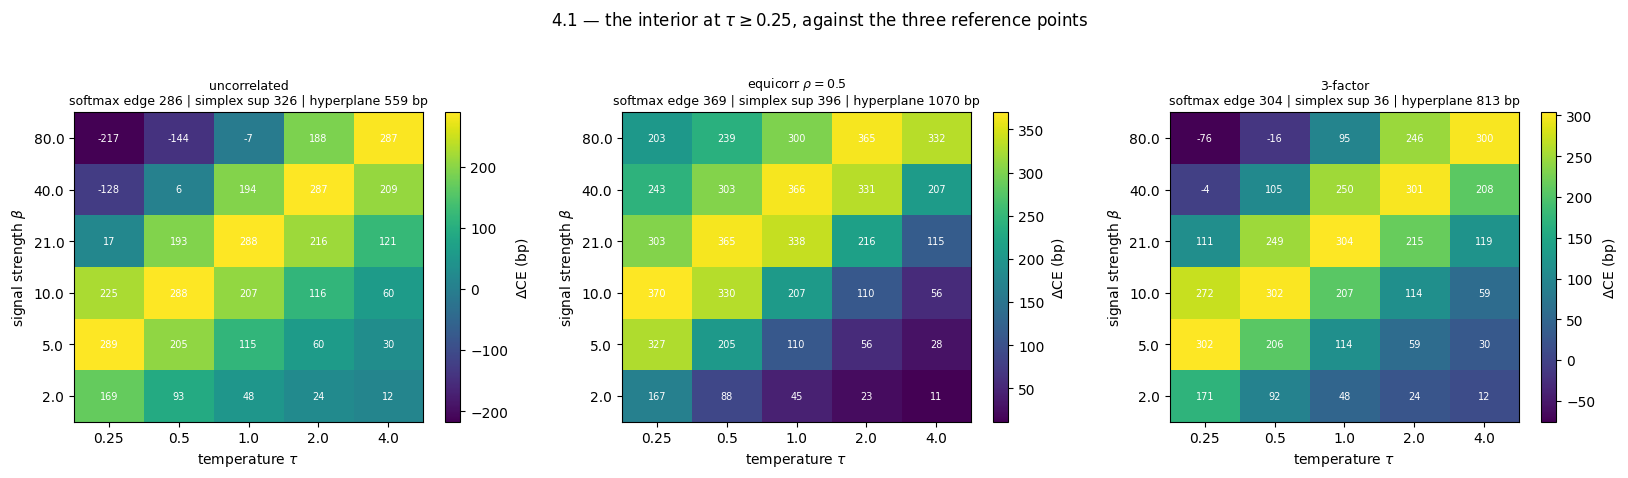

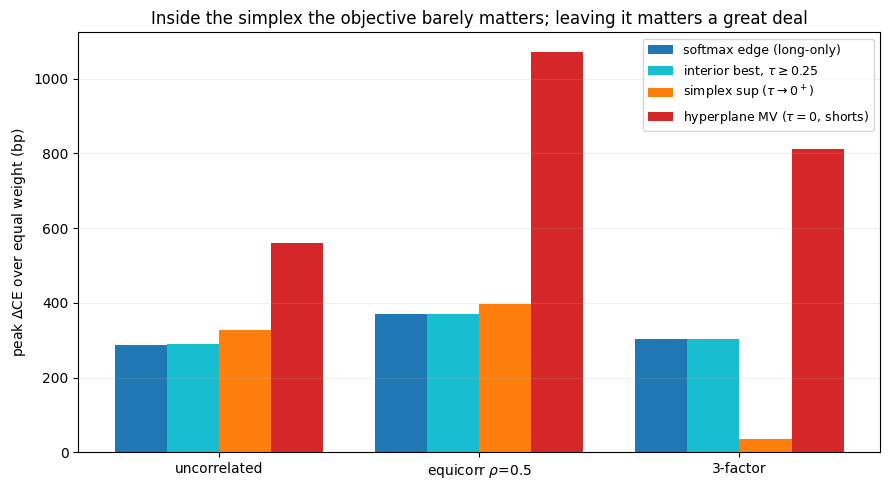

In [24]:
# ---- Experiment 4.1 ----
# Two questions, in order:
#   Q1  within the long-only region (tau > 0): does the interior beat the softmax edge?
#   Q2  releasing it (tau = 0, hyperplane): how much does the freedom to short add?
# The tau > 0 family has no closed form, so its interior is solved by damped iteration; its
# supremum sits at the tau -> 0+ boundary and IS available in closed form, which avoids having
# to push the fixed point into the stiff small-tau region where it fails to converge.

def erm_weights(s, beta, tau, Sigma_dot, iters=300, tol=1e-9, damp=0.5):
    w = np.full_like(s, 1.0 / N)
    for _ in range(iters):
        z = (beta * s - gamma * Sigma_dot(w)) / tau
        z -= z.max(axis=1, keepdims=True)
        w_new = np.exp(z); w_new /= w_new.sum(axis=1, keepdims=True)
        w_next = damp * w + (1 - damp) * w_new
        if np.abs(w_next - w).max() < tol: return w_next
        w = w_next
    return w

def proj_simplex(v):
    u = np.sort(v, axis=1)[:, ::-1]; css = np.cumsum(u, axis=1); j = np.arange(1, v.shape[1] + 1)
    r_ = v.shape[1] - 1 - np.argmax((u - (css - 1) / j > 0)[:, ::-1], axis=1)
    th = (css[np.arange(len(v)), r_] - 1) / (r_ + 1)
    return np.maximum(v - th[:, None], 0.0)

def simplex_sup(s, beta, Sigma_dot, var_eff, lip):
    # tau -> 0+ boundary of the long-only family: max beta s'w - (gamma/2) w'Sigma w over the
    # SIMPLEX. Closed form (water-filling) where Sigma acts as a scalar there; projected
    # gradient otherwise. Unlike the softmax it can set weights to exactly zero.
    if var_eff is not None:
        a = beta * s / (gamma * var_eff)
        lo, hi = a.min(axis=1) - 1.0, a.max(axis=1)
        for _ in range(60):
            mid = (lo + hi) / 2
            tot = np.maximum(a - mid[:, None], 0).sum(axis=1)
            hi = np.where(tot < 1, mid, hi); lo = np.where(tot < 1, lo, mid)
        w = np.maximum(a - ((lo + hi) / 2)[:, None], 0)
        return w / w.sum(axis=1, keepdims=True)
    w = np.full_like(s, 1.0 / N)
    for _ in range(120):
        w = proj_simplex(w + (1.0 / lip) * (beta * s - gamma * Sigma_dot(w)))
    return w

def hyperplane_mv(s, beta, Sig_inv):
    # tau = 0 EDGE: same objective on the budget hyperplane, sign unconstrained.
    # w = (beta/gamma) Sigma^{-1}(s - eta 1), eta fixed by 1'w = 1.
    one = np.ones(N); Sis = s @ Sig_inv.T; Si1 = Sig_inv @ one
    eta = (Sis.sum(axis=1) - gamma / beta) / (one @ Si1)
    return (beta / gamma) * (Sis - eta[:, None] * Si1)

s45 = mu + 0.05 * eps0
rho45 = 0.5
rng_c = np.random.default_rng(4242); z0 = rng_c.standard_normal((n_sims, 1))
R_eq = np.exp((mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*(np.sqrt(rho45)*z0 + np.sqrt(1-rho45)*phi)) - 1.0
k_fac = 3
rng_f = np.random.default_rng(7)
B = np.empty((N, k_fac))
B[:, 0] = 0.45 + 0.15*rng_f.standard_normal(N); B[:, 1:] = 0.30*rng_f.standard_normal((N, k_fac-1))
nrm = np.sqrt((B**2).sum(axis=1)); tb = nrm > 0.95; B[tb] *= (0.95/nrm[tb])[:, None]
idio = 1.0 - (B**2).sum(axis=1)
F = rng_f.standard_normal((n_sims, k_fac))
R_f = np.exp((mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*(F @ B.T + phi*np.sqrt(idio))) - 1.0

S_unc = sigma**2*dt*np.eye(N)
S_eq  = sigma**2*dt*((1-rho45)*np.eye(N) + rho45*np.ones((N, N)))
S_fac = sigma**2*dt*(B @ B.T + np.diag(idio))
cases = {   # returns, Sigma-dot, effective scalar variance on the simplex (or None), Lipschitz, Sigma
 'uncorrelated':              (R,    lambda w: sigma**2*dt*w, sigma**2*dt, None, S_unc),
 fr'equicorr $\rho={rho45}$': (R_eq, lambda w: sigma**2*dt*((1-rho45)*w + rho45*w.sum(axis=1, keepdims=True)),
                               sigma**2*dt*(1-rho45), None, S_eq),
 '3-factor':                  (R_f,  lambda w: sigma**2*dt*((w @ B) @ B.T + w*idio),
                               None, sigma**2*dt*(1 + (B**2).sum(axis=1).max()), S_fac),
}

beta45 = [2.0, 5.0, 10.0, 21.0, 40.0, 80.0]
tau45  = [0.25, 0.5, 1.0, 2.0, 4.0]     # only where the fixed point is verified to converge
rule = "-" * 92
res = {}
for name, (R_c, Sdot, var_eff, lip, Sig) in cases.items():
    ce0 = ce_of(R_c.mean(axis=1))
    surf = np.empty((len(beta45), len(tau45))); thet = np.empty_like(surf)
    for i, b in enumerate(beta45):
        for j, t in enumerate(tau45):
            w = erm_weights(s45, b, t, Sdot)
            surf[i, j] = 1e4*(ce_of((w*R_c).sum(axis=1)) - ce0); thet[i, j] = theta_of(w).mean()
    edge = max(1e4*(ce_of((softmax_weights(s45, b)*R_c).sum(axis=1)) - ce0)
               for b in np.linspace(0, 400, 201))
    sup = (-np.inf, np.nan, np.nan)
    for b in np.linspace(0.05, 3.0, 40):
        w = simplex_sup(s45, b, Sdot, var_eff, lip)
        d = 1e4*(ce_of((w*R_c).sum(axis=1)) - ce0)
        if d > sup[0]: sup = (d, b, (w < 1e-9).sum(axis=1).mean())
    Si = np.linalg.inv(Sig); hyp = (-np.inf, np.nan, np.nan)
    for b in np.linspace(0.02, 3.0, 60):
        w = hyperplane_mv(s45, b, Si)
        with np.errstate(over='ignore'):
            u = np.exp(-gamma*(w*R_c).sum(axis=1))
        if u.max()/u.sum() < msh_max:
            d = 1e4*(-np.log(u.mean())/gamma - ce0)
            if d > hyp[0]: hyp = (d, b, np.abs(np.minimum(w, 0)).sum(axis=1).mean())
    res[name] = (surf, edge, thet, sup, hyp)

print("Q1  LONG-ONLY (tau > 0): does the interior beat the softmax edge?")
print(rule)
print(f"{'Sigma':>20} {'softmax edge':>14} {'interior, tau>=0.25':>20} {'simplex sup (tau->0+)':>22} {'zeros':>8}")
print(rule)
for name, (surf, edge, thet, sup, hyp) in res.items():
    clean = name.replace('$','').replace('\\rho','rho')
    print(f"{clean:>20} {edge:>14.1f} {surf.max():>20.1f} {sup[0]:>22.1f} {sup[2]:>7.1f}/{N}")
print(rule)
print(f"{'gain over the softmax edge':>20} " + " " * 14
      + "".join(f"{surf.max()-edge:>+20.1f}{'':<0}" for _, (surf, edge, _, _, _) in [list(res.items())[0]])[:0]
      + "")
for name, (surf, edge, thet, sup, hyp) in res.items():
    clean = name.replace('$','').replace('\\rho','rho')
    print(f"{clean:>20}   interior {surf.max()-edge:+7.1f} bp      simplex sup {sup[0]-edge:+7.1f} bp")

print(f"\n\nQ2  RELEASING LONG-ONLY (tau = 0, budget hyperplane): what does shorting add?")
print(rule)
print(f"{'Sigma':>20} {'best in simplex':>16} {'hyperplane MV':>15} {'gain':>10} {'short expo':>12}")
print(rule)
for name, (surf, edge, thet, sup, hyp) in res.items():
    clean = name.replace('$','').replace('\\rho','rho')
    best_simplex = max(edge, surf.max(), sup[0])
    print(f"{clean:>20} {best_simplex:>16.1f} {hyp[0]:>15.1f} {hyp[0]-best_simplex:>+10.1f} {hyp[2]:>12.2f}")
print(rule)

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.6))
for ax, (name, (surf, edge, thet, sup, hyp)) in zip(axes, res.items()):
    im = ax.imshow(surf, origin='lower', aspect='auto', cmap='viridis')
    ax.set_xticks(range(len(tau45))); ax.set_xticklabels(tau45)
    ax.set_yticks(range(len(beta45))); ax.set_yticklabels(beta45)
    ax.set_xlabel(r'temperature $\tau$'); ax.set_ylabel(r'signal strength $\beta$')
    ax.set_title(f'{name}\nsoftmax edge {edge:.0f} | simplex sup {sup[0]:.0f} | hyperplane {hyp[0]:.0f} bp',
                 fontsize=9)
    for i in range(len(beta45)):
        for j in range(len(tau45)):
            ax.annotate(f'{surf[i,j]:.0f}', (j, i), ha='center', va='center', fontsize=7, color='white')
    plt.colorbar(im, ax=ax, label=r'$\Delta$CE (bp)')
plt.suptitle(r'4.1 — the interior at $\tau \geq 0.25$, against the three reference points', y=1.03)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(res)); wd = 0.2
for off, key, lab, col in [(-1.5, 'edge', 'softmax edge (long-only)', 'tab:blue'),
                           (-0.5, 'int',  r'interior best, $\tau \geq 0.25$', 'tab:cyan'),
                           ( 0.5, 'sup',  r'simplex sup ($\tau \to 0^+$)', 'tab:orange'),
                           ( 1.5, 'hyp',  r'hyperplane MV ($\tau = 0$, shorts)', 'tab:red')]:
    vals = [ {'edge': e, 'int': s.max(), 'sup': su[0], 'hyp': h[0]}[key]
             for (s, e, _, su, h) in res.values() ]
    ax.bar(x + off*wd, vals, wd, label=lab, color=col)
ax.set_xticks(x); ax.set_xticklabels([n.replace('$','').replace('\\rho',r'$\rho$') for n in res])
ax.set_ylabel(r'peak $\Delta$CE over equal weight (bp)')
ax.set_title('Inside the simplex the objective barely matters; leaving it matters a great deal')
ax.grid(axis='y', alpha=0.2); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

**Reading.** The two questions receive very different answers, and the contrast is the experiment's content.

**Q1 — inside the simplex, the objective barely matters.** At $\tau \geq 0.25$, where the fixed point is verified to converge, the interior improves on the softmax edge by $+2.6$, $+0.4$ and $-0.0$ bp: nothing. Paying the risk charge on top of the diversification charge buys essentially no certainty equivalent, under any of the three risk models, even though $\Sigma$ is supplied exactly. The supremum of the long-only family sits instead at its $\tau \to 0^{+}$ boundary — the *sparse long-only optimum* — and there the picture splits:

* where $\Sigma$ is uninformative — the uncorrelated and equicorrelated cases, in which the names are exchangeable — the sparse optimum gains $+39.9$ and $+26.9$ bp. The mechanism is not covariance-awareness but **sparsity**: the solution has the water-filling form $w_i \propto (\beta s_i - \eta)_+$ and sets $11$–$15$ of $20$ weights to exactly zero, whereas the softmax, being an exponential, keeps every weight strictly positive at every $\beta$. It can exclude names; the softmax can only underweight them. Note that no $\ell_1$ penalty appears anywhere: the sparsity comes from the non-negativity constraint meeting the budget constraint, exactly as in non-negative least squares.
* where $\Sigma$ is heterogeneous — the three-factor case — the same optimum **collapses** to $35.8$ bp, $268$ below the softmax edge, concentrating into roughly three names chosen by the risk model rather than by the signal. Here the entropy term is not redundant machinery: it is what prevents an unregularised risk model from over-concentrating.

The mechanism behind that collapse is worth stating explicitly, because it is the same fact that Q2 will report from the other side. Under a factor $\Sigma$ the mean–variance optimum wants to neutralise factor exposure by **shorting** the high-loading names. Forbid shorting and the programme retains only one instrument for reducing factor exposure: **excluding names outright**. So it discards seventeen of twenty, and the survivors are selected for their loadings rather than for their scores. The sparsity is a symptom of the sign constraint, not a property of the solution.

The conclusion for Q1 is therefore the same in both branches. At these parameters the objective adds at most about $40$ bp inside the long-only region and can subtract several hundred, while the closed-form softmax map captures almost all of what is available. That figure is a measurement at one parameter set, not a bound.

**Q2 — leaving the simplex is worth far more.** Releasing the sign constraint at $\tau = 0$ gains $+233$, $+674$ and $+509$ bp over the best available anywhere inside the simplex, at short exposures of $0.87$ to $2.14$ and with the stability diagnostic comfortable throughout. In level terms the shortable portfolio earns $1.7$ to $2.7$ times the best long-only one ($559$ against $326$, $1070$ against $396$, $813$ against $304$). The comparison worth making is in basis points rather than ratios: the objective can add tens of basis points inside the simplex, and nothing at all in the heterogeneous case, while the feasible set adds several hundred.

**Together.** The binding constraint on this family is the **feasible set, not the objective**. That completes the syllogism begun in Experiment~3.7, where a shortable, $\Sigma$-aware map beat the softmax but the source of the gain could not be attributed: Q1 holds the feasible set fixed and varies the objective, finding almost nothing; Q2 holds the objective fixed and varies the feasible set, finding a great deal. What pays under correlation is therefore not covariance-awareness but the shorting that covariance-awareness recommends — knowledge of $\Sigma$ is close to worthless without the freedom to act on it. It is also what rescues the three-factor case, where the simplex family gains nothing and its sparse optimum collapses, yet the hyperplane earns $813$ bp: heterogeneous risk is not the difficulty, being unable to short while facing it is.

**What survives a change of parameters.** Three of these claims are structural and hold by construction: that the softmax is the $\gamma_r = 0$ edge of the family rather than an approximation to it; that an exponential map can never set a weight to zero while the sparse long-only optimum can; and that the sparsity originates in the constraints rather than in a penalty. The remaining claims are orderings — interior $\approx$ edge, hyperplane $>$ both, sparse optimum $<$ edge under heterogeneous risk — and orderings are what the following cell tests. Every basis-point figure above, by contrast, is specific to this parameter set and should not be carried into a general statement.

**Three caveats.** The interior grid is reported only for $\tau \geq 0.25$; at smaller $\tau$ the fixed-point iteration becomes stiff and stalls before converging, so those cells were excluded rather than reported as data. This costs nothing, because the supremum of the long-only family is available at the boundary and is reported separately. Second, $\gamma_r = \gamma$ throughout: the map is charged for variance at exactly the evaluator's rate. That identity is exact for CARA utility with *Gaussian* returns, but the returns here are lognormal, so the quadratic penalty is an approximation and the best $\gamma_r$ need not equal $\gamma$. This is the one untested parameter that could plausibly overturn Q1 — a map charged less than the evaluator might find the interior genuinely profitable — and it is flagged as such rather than assumed away. Third, $N = 20$ throughout; the balance between diversification and concentration is $N$-dependent, and levels are not comparable across $N$ even where orderings are.

In [25]:
# ---- Experiment 4.1, robustness: does the three-factor collapse depend on the draw of B? ----
# The heterogeneous-risk conclusion above rests on ONE realisation of the loading matrix, drawn at
# seed 7. B is N x 3: column 0 is a "market" factor (all loadings positive, 0.45 +- 0.15), columns
# 1-2 are "style" factors with mixed signs, and each row is capped so that ||B_i||^2 + idio_i = 1.
# Every name therefore carries the SAME total variance -- B generates heterogeneous *correlations*,
# not heterogeneous variances. (Experiment 4.6 is the reverse case.)
#
# Here the factor structure is redrawn four more times. Note that changing the seed redraws the
# loadings B *and* the factor realisations F together, so this measures sampling variation in the
# whole factor block. All five draws come from the same structural family (k = 3, market loading
# 0.45 +- 0.15); alternative families (k = 1, k = 5, wider loading dispersion) are not tested.
def factor_block(seed):
    rf = np.random.default_rng(seed)
    Bs = np.empty((N, k_fac))
    Bs[:, 0]  = 0.45 + 0.15*rf.standard_normal(N)
    Bs[:, 1:] = 0.30*rf.standard_normal((N, k_fac-1))
    nm = np.sqrt((Bs**2).sum(axis=1)); big = nm > 0.95
    Bs[big] *= (0.95/nm[big])[:, None]
    idi = 1.0 - (Bs**2).sum(axis=1)
    Fs  = rf.standard_normal((n_sims, k_fac))
    return Bs, idi, Fs

b_seeds = [7, 1, 2, 3, 4]
bres = {}
for sd in b_seeds:
    Bs, idi, Fs = factor_block(sd)
    R_s   = np.exp((mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*(Fs @ Bs.T + phi*np.sqrt(idi))) - 1.0
    Sdot_s = lambda w, Bs=Bs, idi=idi: sigma**2*dt*((w @ Bs) @ Bs.T + w*idi)
    lip_s  = sigma**2*dt*(1 + (Bs**2).sum(axis=1).max())
    Sig_s  = sigma**2*dt*(Bs @ Bs.T + np.diag(idi))
    ce0_s  = ce_of(R_s.mean(axis=1))

    edge_s = max(1e4*(ce_of((softmax_weights(s45, b)*R_s).sum(axis=1)) - ce0_s)
                 for b in np.linspace(0, 400, 201))
    sup_s = (-np.inf, np.nan)
    for b in np.linspace(0.05, 3.0, 30):
        w = simplex_sup(s45, b, Sdot_s, None, lip_s)
        d = 1e4*(ce_of((w*R_s).sum(axis=1)) - ce0_s)
        if d > sup_s[0]: sup_s = (d, (w < 1e-9).sum(axis=1).mean())
    Si_s = np.linalg.inv(Sig_s); hyp_s = (-np.inf, np.nan)
    for b in np.linspace(0.02, 3.0, 60):
        w = hyperplane_mv(s45, b, Si_s)
        with np.errstate(over='ignore'):
            u = np.exp(-gamma*(w*R_s).sum(axis=1))
        if u.max()/u.sum() < msh_max:
            d = 1e4*(-np.log(u.mean())/gamma - ce0_s)
            if d > hyp_s[0]: hyp_s = (d, np.abs(np.minimum(w, 0)).sum(axis=1).mean())
    C_s = Bs @ Bs.T; np.fill_diagonal(C_s, 1.0); off_s = C_s[~np.eye(N, dtype=bool)]
    bres[sd] = (off_s.mean(), off_s.min(), off_s.max(), idi.mean(),
                edge_s, sup_s[0], sup_s[1], hyp_s[0], hyp_s[1])

print("Three-factor case, five independent draws of the factor block")
print("(everything else fixed: N, sigma, mu_bar, sigma_mu, sigma_eps, gamma_r = gamma, CRN seed 42)")
print(rule)
print(f"{'seed':>5} {'corr mean':>10} {'min':>7} {'max':>6} {'idio':>6} | {'edge':>7} {'sup':>7} "
      f"{'sup-edge':>9} {'zeros':>8} | {'hyper':>8} {'hyp/edge':>9} {'short':>6}")
print(rule)
for sd in b_seeds:
    cm, cmin, cmax, idm, e_, s_, z_, h_, sh_ = bres[sd]
    tag = "  <- the draw used above" if sd == 7 else ""
    print(f"{sd:>5} {cm:>10.2f} {cmin:>7.2f} {cmax:>6.2f} {idm:>6.2f} | {e_:>7.1f} {s_:>7.1f} "
          f"{s_-e_:>+9.1f} {z_:>5.1f}/{N} | {h_:>8.1f} {h_/e_:>9.2f} {sh_:>6.2f}{tag}")
print(rule)
arr = np.array([[bres[sd][4], bres[sd][5]-bres[sd][4], bres[sd][7], bres[sd][6], bres[sd][8]]
                for sd in b_seeds])
for j, lab in enumerate(['softmax edge', 'sup - edge', 'hyperplane', 'zeros', 'short exposure']):
    print(f"{lab:>16}:  min {arr[:, j].min():>8.1f}   max {arr[:, j].max():>8.1f}   "
          f"mean {arr[:, j].mean():>8.1f}   sd {arr[:, j].std(ddof=1):>6.1f}")
print(rule)
n_ = len(b_seeds)
print(f"orderings:  sup < edge in {sum(bres[s][5] < bres[s][4] for s in b_seeds)}/{n_} draws;  "
      f"hyperplane > edge in {sum(bres[s][7] > bres[s][4] for s in b_seeds)}/{n_};  "
      f"hyperplane > sup in {sum(bres[s][7] > bres[s][5] for s in b_seeds)}/{n_}.")
print(f"the draw reported above (seed 7) gives the LARGEST collapse of the five; the mean is "
      f"{arr[:, 1].mean():.1f} bp, not {arr[0, 1]:.1f}.")

Three-factor case, five independent draws of the factor block
(everything else fixed: N, sigma, mu_bar, sigma_mu, sigma_eps, gamma_r = gamma, CRN seed 42)
--------------------------------------------------------------------------------------------
 seed  corr mean     min    max   idio |    edge     sup  sup-edge    zeros |    hyper  hyp/edge  short
--------------------------------------------------------------------------------------------
    7       0.16   -0.21   0.57   0.66 |   303.8    36.2    -267.7  17.5/20 |    812.8      2.68   1.55  <- the draw used above
    1       0.20   -0.17   0.56   0.63 |   316.8   122.4    -194.4  17.2/20 |    866.1      2.73   1.74
    2       0.19   -0.47   0.53   0.59 |   306.6    68.1    -238.5  17.6/20 |    946.7      3.09   1.67
    3       0.17   -0.40   0.78   0.63 |   308.5    72.8    -235.7  17.4/20 |    979.6      3.18   1.99
    4       0.19   -0.27   0.57   0.63 |   309.5   102.8    -206.6  17.3/20 |    895.4      2.89   1.55
-----------

**Reading (robustness).** The heterogeneous-risk conclusion is not an artefact of the draw. Across five independent factor blocks the three orderings hold **5/5**: the sparse long-only optimum falls below the softmax edge, the hyperplane beats the edge, and the hyperplane beats the sparse optimum.

What is stable and what is not separates cleanly. The **softmax edge is very stable** — a spread of $303.8$ to $316.8$ bp, standard deviation $4.8$ — which is what one would expect of a map that never looks at $\Sigma$: it barely notices which correlation structure it is facing. The **sparsity is essentially invariant**, $17.2$ to $17.6$ zeros of $20$, confirming that the mechanism belongs to the constraint geometry rather than to any particular $B$. What varies is the **magnitude of the collapse**, from $-194.4$ to $-267.7$ bp with a standard deviation of $28.8$ — a $13\%$ coefficient of variation against $1.6\%$ for the edge.

One consequence matters for how the result is quoted. **The draw used in the main experiment, seed 7, produces the largest collapse of the five**; the mean is $-228.6$ bp rather than $-267.7$. Nothing selected it that way — it is simply the first seed tried — but the headline figure is therefore at the pessimistic end of its own sampling distribution, and the defensible claim is the ordering together with its range, not the single number.

**Two limits on what this establishes.** Changing the seed redraws the loadings $B$ and the factor realisations $F$ *together*, so this is sampling variation in the whole factor block rather than in $B$ alone. And all five draws come from one structural family — three factors, market loading $0.45 \pm 0.15$, total variance normalised to one. Alternative families (a single factor, five factors, wider loading dispersion, or loadings that do not normalise total variance) are not tested, so the claim supported is robustness to the *draw*, not to the *kind* of factor model.

## Experiment 4.2 — Which signals can a map hear?

The drift cross-section now carries a random common component, $\mu_i = \bar\mu + M + \sigma_\mu z_i$ with $M \sim \mathcal{N}(0, 0.05^2)$ redrawn each replication — some years are good for everything, some bad — and the investor receives, alongside the baseline drift signal, a clean **market-level signal** $s_M = M$: a view about the *level* of returns carrying no cross-sectional information whatsoever.

The two maps differ structurally in whether they can hear it. Adding $\lambda_M s_M \mathbf{1}$ to the score vector leaves the softmax's weights untouched to machine precision (Lemma 3.8); the combination map's normaliser shifts, so its weights move. The interesting question is whether moving *helps*. Under full investment it should not: with $\mathbf{1}^\top w = 1$, every portfolio earns the common component $M$ alike, so $s_M$ carries no information any fully invested allocation can monetise — to first order, the level is *allocationally irrelevant*. A map that responds to it is responding to noise it happens to be able to hear. The experiment sweeps the loading $\lambda_M$ and traces $\Delta$CE for the combination map (at each $\lambda_M$'s own re-optimised $\alpha$, with the Chapter 3 guard and diagnostic), against the softmax's provably flat line.
The words "to first order" are doing real work, and it is worth saying now what the second order contains, because the robustness cell below shows it is not negligible everywhere. The first-order statement concerns **exposure**, and it is exact: since $M$ enters the drift additively, gross returns factor as $1 + R_i = e^{M\Delta t}(1 + R_i^0)$, so $1 + P = e^{M\Delta t}(1 + P^0)$ for *any* fully invested $w$, and no reallocation can increase or decrease what the portfolio earns from $M$. What that argument does not cover is **scale**. CARA utility is defined on absolute profit and loss, so an identical tilt puts more at risk in a good year than in a bad one; a fully invested investor cannot change exposure to $M$ but does have a preference over how much cross-sectional risk to run *given* $M$. A map whose weights respond to the level is therefore not necessarily responding to noise — it may be implementing a crude state-dependent aggressiveness rule.

The combination map does exactly that, and in the helpful direction. Writing $w_{\mathrm{sig},i} = (s_i + \lambda_M M)/(\mathbf{1}^\top s + N\lambda_M M)$, a large positive $M$ drives every weight towards $1/N$ while a negative $M$ drives them apart, so listening makes the map *less* aggressive precisely when the stakes are high. Against that sits the map's singularity: $w_{\mathrm{sig}}$ is undefined where the normaliser vanishes, and adding $\lambda_M M$ inflates the variance of $\mathbf{1}^\top s$ without diluting it, since $M$ is common to every name. The experiment therefore contains two opposing effects rather than one, and which of them dominates is an empirical question about how far $\mathbf{1}^\top s$ sits from zero. The main cell answers it at the chapter's baseline; the robustness cell that follows separates the two channels and locates the boundary between them.

softmax under market-signal loadings: max |weight difference| = 7.22e-16


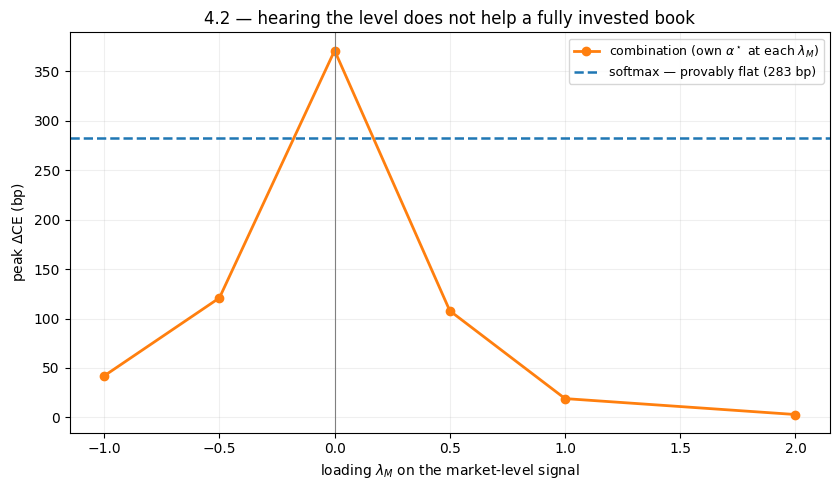


 lambda_M  comb peak dCE  alpha*  dropped  maxshare@opt
     -1.0           42.0    0.23     1569         0.03%
     -0.5          120.9    0.38      962         0.08%
      0.0          371.2    1.15       41         0.37%
      0.5          107.8    0.30      981         0.21%
      1.0           19.0    0.15     1528         0.03%
      2.0            2.9    0.08     1578         0.01%


In [29]:
# ---- Experiment 4.2 ----
mu_M = mu + M_mkt                    # drifts with the common component
R_M  = np.exp((mu_M - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * phi) - 1.0
s_dr = mu + 0.05 * eps0              # baseline drift signal (cross-sectional part; noise as ever)

# softmax: exact inaudibility, verified
w0 = softmax_weights(s_dr, 21.0)
dev = max(np.abs(softmax_weights(s_dr + lam * M_mkt, 21.0) - w0).max() for lam in [0.5, 1.0, 2.0])
print(f"softmax under market-signal loadings: max |weight difference| = {dev:.2e}")

def comb_best_alpha(s_l, R_mat, grid=np.linspace(0, 2, 81)):
    ns = s_l.sum(axis=1)
    m = np.abs(ns) > 0.10 * np.median(np.abs(ns))
    w_s, R_m = s_l[m] / ns[m, None], R_mat[m]
    p_eq, p_sig = R_m.mean(axis=1), (w_s * R_m).sum(axis=1)
    ce0 = -np.log(np.exp(-gamma * p_eq).mean()) / gamma
    best = (-np.inf, np.nan, np.nan)
    for a in grid:
        with np.errstate(over='ignore'):
            u = np.exp(-gamma * ((1 - a) * p_eq + a * p_sig))
        if u.max() / u.sum() < msh_max:
            d = 1e4 * (-np.log(u.mean()) / gamma - ce0)
            if d > best[0]: best = (d, a, u.max() / u.sum())
    return best + (int((~m).sum()),)

lamM_grid = [-1.0, -0.5, 0.0, 0.5, 1.0, 2.0]
res44 = {lam: comb_best_alpha(s_dr + lam * M_mkt, R_M) for lam in lamM_grid}
sfmx_pk, sfmx_b = best_beta(s_dr, R_M)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(lamM_grid, [res44[l][0] for l in lamM_grid], 'o-', lw=2, color='tab:orange',
        label=r'combination (own $\alpha^\star$ at each $\lambda_M$)')
ax.axhline(sfmx_pk, color='tab:blue', ls='--', lw=1.8,
           label=fr'softmax — provably flat ({sfmx_pk:.0f} bp)')
ax.axvline(0, color='grey', lw=0.8)
ax.set_xlabel(r'loading $\lambda_M$ on the market-level signal')
ax.set_ylabel(r'peak $\Delta$CE (bp)')
ax.set_title('4.2 — hearing the level does not help a fully invested book')
ax.grid(alpha=0.2); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"\n{'lambda_M':>9} {'comb peak dCE':>14} {'alpha*':>7} {'dropped':>8} {'maxshare@opt':>13}")
for l in lamM_grid:
    d, a, msh, drop = res44[l]
    print(f"{l:>9} {d:>14.1f} {a:>7.2f} {drop:>8} {msh:>13.2%}")

**Reading.** The audibility split is exact, and the economics behind it is more interesting than the prediction anticipated.

**The softmax cannot hear the signal, and this is arithmetic.** Its weights do not move under any market-signal loading — $7 \times 10^{-16}$, machine precision — because $\operatorname{softmax}(\beta(s + c\mathbf{1})) = \operatorname{softmax}(\beta s)$ identically. No choice of parameters can disturb it, so the figure verifies an identity rather than measuring an effect.

**The combination map hears it loudly, and at these parameters is hurt by every amount of listening.** At $\lambda_M = 0$ the map earns its usual $371$ bp; at $\lambda_M = \pm 0.5$ the peak collapses to $108$–$121$ bp and the normaliser guard's dropped count rises from $41$ to nearly a thousand. The channel is the map's singularity. Shifting all scores by a common amount moves $\mathbf{1}^\top s$ towards zero on many more draws, and $w_{\mathrm{sig}} = s/(\mathbf{1}^\top s)$ is undefined there — the level enters the map through exactly its most fragile part. Two features of that channel are worth recording. First, $M$ is *common to every name*, so its contribution to the normaliser is undiluted, whereas the idiosyncratic terms enter divided by $N$: a loading of $\lambda_M = 0.5$ does what $\sigma_\mu$ would need to reach $0.10$ to achieve. Second, the guard catches this failure but is blind to its mirror image — a market so poor that $\mathbf{1}^\top s$ is *systematically* negative produces no small normalisers at all, so nothing is dropped and every weight is quietly inverted.

**Whether the damage is inevitable is a question the baseline cannot answer, and the robustness cell shows it is not.** The first-order argument — that every fully invested portfolio earns $M$ alike, so the level cannot be monetised — is exactly right about *exposure* and silent about *scale*. Because CARA is defined on absolute P&L, the same tilt risks more in a good year, and the combination map's response to $M$ happens to reduce the tilt when $M$ is large. That is a genuine, if crude, state-dependent aggressiveness control, and where the normaliser sits comfortably away from zero it is worth having: at $\bar\mu = 0.10$, listening at $\lambda_M = 0.25$–$0.5$ *gains* about $15$ bp, systematically across independent draws of the market component. The response is therefore not "pure self-harm" in general; it is self-harm wherever the pole is close, which includes the baseline and everything below it.

The stylised fact survives with its scope made explicit: **maps differ in which signals they can hear, and audibility is exposure rather than virtue.** A map should be able to hear exactly the signals whose content its feasible set can act on — and the useful refinement is that the fully-invested constraint makes the market level *almost*, but not entirely, unactionable. It fixes what the portfolio earns from $M$; it does not fix how much cross-sectional risk the investor wishes to carry given $M$. Restoring a cash asset would make the level actionable in the first sense as well, scaling into and out of the market, and would reverse the ranking outright; the experiment thus marks precisely which ingredient makes deafness close to optimal, and precisely how far "close" falls short of exact.

In [30]:
# ---- Experiment 4.2, robustness: does the audibility result depend on the market? ----
# Two claims are under test and they have very different standing.
#
#   (i)  The softmax cannot hear M. This is ALGEBRA: softmax(beta*(s + c*1)) = softmax(beta*s)
#        for any scalar c, so no parameter can disturb it. Verified, not measured.
#
#   (ii) Hearing M harms the combination map. This is NOT structural, and the sweep below shows
#        the baseline result is a statement about a region rather than a universal law. Two
#        opposing channels are at work.
#
#        THE POLE. w_sig = s/(1's) is singular where the normaliser vanishes, and
#            1's/N  ~  N( mu_bar,  (sigma_mu^2 + sigma_eps^2)/N  +  lam_M^2 * sigma_M^2 ),
#        so mu_bar sets the LOCATION, lam_M adds UNDILUTED dispersion (M is common to all names)
#        and sigma_mu, sigma_eps add dispersion divided by N. sigma does not enter at all; it
#        touches only the evaluation. Raising lam_M drives the normaliser towards zero and the
#        weights explode.
#
#        THE STAKES CHANNEL. Because M enters the drift additively, gross returns factor as
#            1 + R_i = exp(M*dt)*(1 + R_i^0)   and hence   1 + P = exp(M*dt)*(1 + P^0)
#        for ANY fully invested w. So no allocation choice alters EXPOSURE to M -- but CARA is
#        defined on absolute P&L, so the same tilt risks more in a good year than in a bad one.
#        Adding lam*M to every score sends w_sig towards 1/N when M is large and away from it when
#        M is small, i.e. it tilts LESS when the stakes are high. That is a crude but genuine
#        state-dependent aggressiveness control, and it is worth something.
#
# Which channel wins depends on how far the normaliser sits from zero. The sweep separates them.
sig_M42, sig_eps42 = 0.05, 0.05
settings = [(0.05, 0.05, 0.20), (0.05, 0.05, 0.15), (0.05, 0.05, 0.30),
            (0.05, 0.10, 0.20), (0.10, 0.05, 0.20), (0.02, 0.05, 0.20)]
lam42 = [0.0, 0.25, 0.5, 1.0, 2.0]

def market42(mb, smu, sg):
    r  = np.random.default_rng(42)                       # the chapter's CRN construction
    m  = mb + smu*r.standard_normal((n_sims, N))
    e_ = r.standard_normal((n_sims, N)); p_ = r.standard_normal((n_sims, N))
    Rm = np.exp((m + M_mkt - 0.5*sg**2)*dt + sg*np.sqrt(dt)*p_) - 1.0
    return m + sig_eps42*e_, Rm

def comb_peak42(s_l, R_mat, grid=np.linspace(0, 2, 81)):
    ns   = s_l.sum(axis=1)
    keep = np.abs(ns) > 0.10*np.median(np.abs(ns))       # the chapter's normaliser guard
    w_sig, R_k = s_l[keep]/ns[keep, None], R_mat[keep]
    c0 = ce_of(R_k.mean(axis=1)); best = -np.inf
    for a in grid:
        d = 1e4*(ce_of((((1.0-a)/N + a*w_sig)*R_k).sum(axis=1)) - c0)
        if d > best: best = d
    return best, n_sims - int(keep.sum())

print("Does the audibility result survive a change of market?   (sigma_eps = sigma_M = 0.05, N = 20)")
print(rule)
print(f"{'mu_bar':>7}{'sig_mu':>7}{'sigma':>6}{'SNR':>7} |" + "".join(f"{f'lam={l}':>9}" for l in lam42)
      + f" | {'best lam':>9}{'vs lam=0':>10}")
print(rule)
res42r = {}
for mb, smu, sg in settings:
    s_c, R_c = market42(mb, smu, sg)
    vals = [comb_peak42(s_c + l*M_mkt, R_c)[0] for l in lam42]
    drops = [comb_peak42(s_c + l*M_mkt, R_c)[1] for l in (0.0, 0.5)]
    snr = mb/np.sqrt((smu**2 + sig_eps42**2)/N)
    bl  = lam42[int(np.argmax(vals))]
    res42r[(mb, smu, sg)] = (vals, drops, snr, bl)
    tag = "  <- chapter baseline" if (mb, smu, sg) == (0.05, 0.05, 0.20) else ""
    print(f"{mb:>7.2f}{smu:>7.2f}{sg:>6.2f}{snr:>7.2f} |" + "".join(f"{v:>9.1f}" for v in vals)
          + f" | {bl:>9.2f}{max(vals)-vals[0]:>+10.1f}{tag}")
print(rule)
w_ref = softmax_weights(market42(*settings[0])[0], 21.0)
devs = []
for mb, smu, sg in settings:
    s_c, _ = market42(mb, smu, sg); wr = softmax_weights(s_c, 21.0)
    devs.append(max(np.abs(softmax_weights(s_c + l*M_mkt, 21.0) - wr).max() for l in [0.5, 1.0, 2.0]))
print(f"softmax: max |weight difference| over every setting and loading = {max(devs):.0e} "
      f"(machine precision, as shift-invariance requires)")

# the stakes channel, made visible: how the tilt co-moves with the market year
print(f"\nthe stakes channel -- gross tilt |w - 1/N|_1 against the market year, at the baseline:")
print(rule)
print(f"{'lam_M':>7}{'corr(M, tilt)':>15}{'mean tilt | M<0':>18}{'mean tilt | M>0':>18}")
print(rule)
s_b, _ = market42(*settings[0])
for l in [0.0, 0.25, 0.5, 1.0]:
    s_l = s_b + l*M_mkt
    ns = s_l.sum(axis=1); keep = np.abs(ns) > 0.10*np.median(np.abs(ns))
    tilt = np.abs(s_l[keep]/ns[keep, None] - 1.0/N).sum(axis=1); Mk = M_mkt[keep, 0]
    print(f"{l:>7.2f}{np.corrcoef(Mk, tilt)[0, 1]:>15.3f}{tilt[Mk < 0].mean():>18.3f}{tilt[Mk > 0].mean():>18.3f}")
print(rule)
print("at lam_M = 0 the tilt is uncorrelated with the market year; switching the market signal on")
print("makes the map systematically less aggressive in good years and more aggressive in bad ones.")

Does the audibility result survive a change of market?   (sigma_eps = sigma_M = 0.05, N = 20)
------------------------------------------------------------------------------
 mu_bar sig_mu sigma    SNR |  lam=0.0 lam=0.25  lam=0.5  lam=1.0  lam=2.0 |  best lam  vs lam=0
------------------------------------------------------------------------------
   0.05   0.05  0.20   3.16 |    371.2    231.3    107.8     19.0      2.9 |      0.00      +0.0  <- chapter baseline
   0.05   0.05  0.15   3.16 |    561.3    319.9    146.9     26.4      4.0 |      0.00      +0.0
   0.05   0.05  0.30   3.16 |    178.1    124.3     60.4     10.3      1.7 |      0.00      +0.0
   0.05   0.10  0.20   2.00 |    331.1    275.9    157.1     40.9      5.5 |      0.00      +0.0
   0.10   0.05  0.20   6.32 |    397.6    408.0    412.6    150.9     22.2 |      0.50     +15.0
   0.02   0.05  0.20   1.26 |     65.9     27.6     10.6      1.3      0.0 |      0.00      +0.0
------------------------------------------------

**Reading (robustness).** The two claims of this experiment survive a change of market very differently, and the contrast is worth the cell.

**The softmax's deafness is untouchable.** Across every setting and every loading the weights move by at most $7 \times 10^{-16}$. This is not evidence; it is arithmetic, since $\operatorname{softmax}(\beta(s + c\mathbf{1})) = \operatorname{softmax}(\beta s)$ identically. No parameter can disturb it, and the experiment reports it only so that the reader can see the identity holding in the code.

**The combination map's self-harm is a statement about a region, not a law.** At the chapter's baseline, and in every setting where the market drift is $0.05$ or below, the map is hurt by any amount of listening and the damage is severe — between $53\%$ and $84\%$ of its value at $\lambda_M = 0.5$. But at $\bar\mu = 0.10$ the ordering **reverses**: listening at $\lambda_M = 0.25$–$0.5$ is worth about $+15$ bp, and the effect is systematic rather than sampling noise, appearing in five independent draws of the market component.

Two opposing channels explain this, and separating them is more informative than the original claim.

*The pole.* The map $w_{\mathrm{sig}} = s/(\mathbf{1}^\top s)$ is singular where the normaliser vanishes, and
$$
\frac{\mathbf{1}^\top s}{N} \;\sim\; \mathcal{N}\!\left(\bar\mu,\ \frac{\sigma_\mu^2 + \sigma_\varepsilon^2}{N} \;+\; \lambda_M^2\sigma_M^2\right).
$$
So $\bar\mu$ fixes the *location*, $\lambda_M$ adds *undiluted* dispersion — $M$ is common to every name and therefore does not average down — and $\sigma_\mu, \sigma_\varepsilon$ add dispersion divided by $N$. That asymmetry matters: $\sigma_\mu$ would have to reach $0.10$ to do what $\lambda_M = 0.5$ does. And $\sigma$ does not appear at all, which is why the three rows differing only in $\sigma$ have *identical* drop counts and nearly identical proportional damage — $\sigma$ scales the evaluation, not the map.

*The stakes channel.* Because $M$ enters the drift additively, gross returns factor as $1 + P = e^{M\Delta t}(1 + P^0)$ for **any** fully invested $w$, so no allocation choice alters exposure to $M$. But CARA is defined on absolute P&L, so an identical tilt risks more in a good year than in a bad one. Adding $\lambda_M M$ to every score pushes $w_{\mathrm{sig}}$ towards $1/N$ when $M$ is large and away from it when $M$ is small: the map becomes **less aggressive when the stakes are high**. The diagnostic makes this explicit — the correlation between the market year and the gross tilt is $-0.008$ at $\lambda_M = 0$ and $-0.444$ at $\lambda_M = 0.25$, with mean tilt rising from $1.02$ in good years to $1.71$ in bad ones. That is a crude but real state-dependent aggressiveness control, and it has value.

Which channel dominates is decided by how far the normaliser sits from zero, indexed here by $\mathrm{SNR} = \bar\mu / \sqrt{(\sigma_\mu^2+\sigma_\varepsilon^2)/N}$. At $\mathrm{SNR} = 6.32$ the pole is remote, the stakes channel shows through, and a little listening pays. At $3.16$ and below the pole dominates from the first increment. In every setting the map is destroyed by $\lambda_M \geq 1$, so the benefit — where it exists at all — is confined to a narrow window of small loadings.

**What this does to the chapter's claim.** The stylised fact stands but needs its scope stated: audibility is *exposure*, and a map should be able to hear exactly the signals its feasible set can act on. What the sweep adds is that the market level is not quite unactionable even under full investment — it cannot change exposure to $M$, but it can change *how much risk to take given* $M$, and a fully invested CARA investor does have a preference about that. The original wording, that the response is "pure self-harm", is right at the baseline and wrong at $\bar\mu = 0.10$; the defensible statement is that the cost of audibility is severe wherever the normaliser is not comfortably bounded away from zero, and that this covers the whole of the parameter region the thesis otherwise studies.

## Experiment 4.3 — The firewall as a dial

The variance budget of a one-step log-return splits into a drift part and a diffusion part: cross-sectionally, $\operatorname{Var} = \sigma_\mu^2\,\Delta t^2 + \sigma^2 \Delta t = 0.0025 + 0.04$, so the shock owns roughly $94\%$ of what separates winners from losers in a single year — and the firewall of Definition 3.1 keeps every clean signal away from it. The claim under test: **a signal's value scales with the share of return variance it addresses, not with its detail.**

**A scope note before the results.** Every quantity in this experiment is computed under the Gibbs map, $w \propto \exp(\beta s)$, and is therefore **long-only**: the weights lie on the simplex, so a signal can be acted on by overweighting but never by excluding a name or shorting it. The combination map is not tested here, and the omission matters unevenly. The top-$k$ ladder would transfer almost unchanged, because the combination map at $\alpha = 1$ places $1/k$ on each named name and the softmax converges to that same portfolio as $\beta \to \infty$ — the ladder is essentially common to both maps, which is also why the entropy deficit saturates at $\theta_{\max}(k)$ in part (b). What would *not* transfer is the price paid for it: under the combination map the drift signal meets the normaliser pole, so its value depends on $\bar\mu$ directly rather than only through the scale. The exchange rate, the scaling laws, and the level-versus-volatility comparison below are therefore statements about the Gibbs map alone.

**(a) The information dial.** Let
$$
s_i(b) \;=\; \mu_i \;+\; b\,\sigma\sqrt{\Delta t}\,\phi_i \;+\; \sigma_\varepsilon\,\varepsilon_i ,
$$
so $b=0$ is the ordinary noisy drift signal and $b$ raises the fraction of the diffusion shock the signal sees. The share of return variance addressed is explicit, $\mathrm{share}(b) = (\sigma_\mu^2 + b^2\sigma^2\Delta t)/(\sigma_\mu^2 + \sigma^2\Delta t)$, so the claim becomes a curve the simulation can trace. Economically, $b$ indexes the investor's *kind* of edge: $b=0$ is fundamental analysis (views about expected returns), $b>0$ is event information — nowcasting, order flow, at the illegal extreme insider knowledge — views about what is about to happen.

It is worth being precise about what $b$ is not. It is not a licence to see the future. The split between "drift" and "shock" is a property of the *model's* information set, not of the world: what the geometric Brownian motion calls an unpredictable increment is unpredictable **relative to that filtration**, and an analyst who anticipates an earnings surprise, or who nowcasts from higher-frequency data, forecasts part of it. So $b$ measures informational advantage relative to the model's filtration. Part (f) shows that it is also a *numeraire* — a unit in which any other signal can be priced.

**(b) The top-$k$ signal.** The indicator of membership in the $k$ best *realised* performers: one bit per name, no magnitudes, no ordering within the set — Felix's example of coarsened look-ahead. Under the softmax any two-level score vector is equivalent (levels are absorbed by $\beta$ and the shift-invariance), so the map is simply $\operatorname{softmax}(\beta\,\mathbf{1}\{i \in \text{top-}k\})$, and as $\beta \to \infty$ it converges to *uniform on the $k$ members*: the entropy deficit saturates at $\theta_{\max}(k) = 1 - \ln k / \ln N$, so coarseness caps the achievable concentration — the set-valued format can never reach the oracle corner. The dial runs $k = N$ (no information) towards $k=1$ (near-oracle). Prediction: **top-5 beats the clean drift signal** despite carrying one bit per name, because it addresses the dominant variance component.

**(e) The right coordinates.** The pair $(\sigma_\mu, \sigma)$ is a poor parameterisation. At $\Delta t = 1$ both enter the log return as Gaussian shifts with the same scaling,
$$
x_i \;=\; \text{const} \;+\; \sigma_\mu z_i \;+\; \sigma\phi_i ,
$$
so from returns alone only $\sigma_\mu^2 + \sigma^2$ is identified: the two are *observationally equivalent*. What separates them is the signal, which sees $\mu$ (hence $z$) and never $\phi$. The economically meaningful coordinates are therefore
$$
\Omega \;=\; \sqrt{\sigma_\mu^2\Delta t^2 + \sigma^2\Delta t}, \qquad
\mathrm{share} \;=\; \frac{\sigma_\mu^2\Delta t^2}{\Omega^2},
$$
the total cross-sectional spread — which is *observable*, and which the empirical dispersion literature measures directly — and the predictable fraction, which is *latent* and is precisely what cannot be read off returns. Sweeping $\sigma_\mu$ at fixed $\sigma$, as an earlier version of this experiment did, moves both at once and so confounds information content with risk scale. The sweep below holds $\Omega$ fixed and moves only the share.

**(h) The exchange rate as a function.** Part (c) prices the drift signal against the ladder at one parameter set. Since (e) shows the ladder is flat in the share while the drift signal is not, that price cannot be a constant; inverting the ladder market by market turns it into a function $k^\star(\mathrm{share})$, reported as $N - k^\star$, the number of names one would have to be able to exclude to match a clean drift signal.

**(i) Market regimes.** Four regimes are carried, indexed by $\bar\mu$ (bull/bear) and by $(\sigma_\mu, \sigma)$ jointly (calm/turbulent), the latter because cross-sectional dispersion and aggregate volatility are both countercyclical. The drift levels are the bull and bear state means of Maheu, McCurdy and Song; the volatility ratio follows the two-state estimates surveyed in Ang (2011), though the *levels* are anchored to the Chapter 3 baseline because those are index volatilities and $\sigma$ here is a single-name volatility. Note that $\bar\mu$ cannot move the share — it is common to every name and cancels from the cross-sectional variance — so the bull/bear axis is a test of the map's mechanics, not of its information content. That is Experiment 4.2's result, and (i) confirms it holds here.

variance budget at the baseline: drift 5.9%, diffusion shock 94.1%
total cross-sectional spread Omega = 0.2062
clean drift signal: 477.3 bp at beta* = 36

(a) THE INFORMATION DIAL
------------------------------------------------------------------------------
     b  shock seen     b^2  share added  total share   peak dCE   beta*
------------------------------------------------------------------------------
   0.0         0%   0.000        0.0%         5.9%      286.3      21
   0.1        10%   0.010        0.9%         6.8%     1111.3      39
  0.25        25%   0.062        5.9%        11.8%     2293.0      62
   0.5        50%   0.250       23.5%        29.4%     3385.0     108
   1.0       100%   1.000       94.1%       100.0%     3948.5     120
------------------------------------------------------------------------------

(b) TOP-k LADDER
------------------------------------------------------------------------------
   k  of universe  names excluded   peak dCE   x clean  theta@op

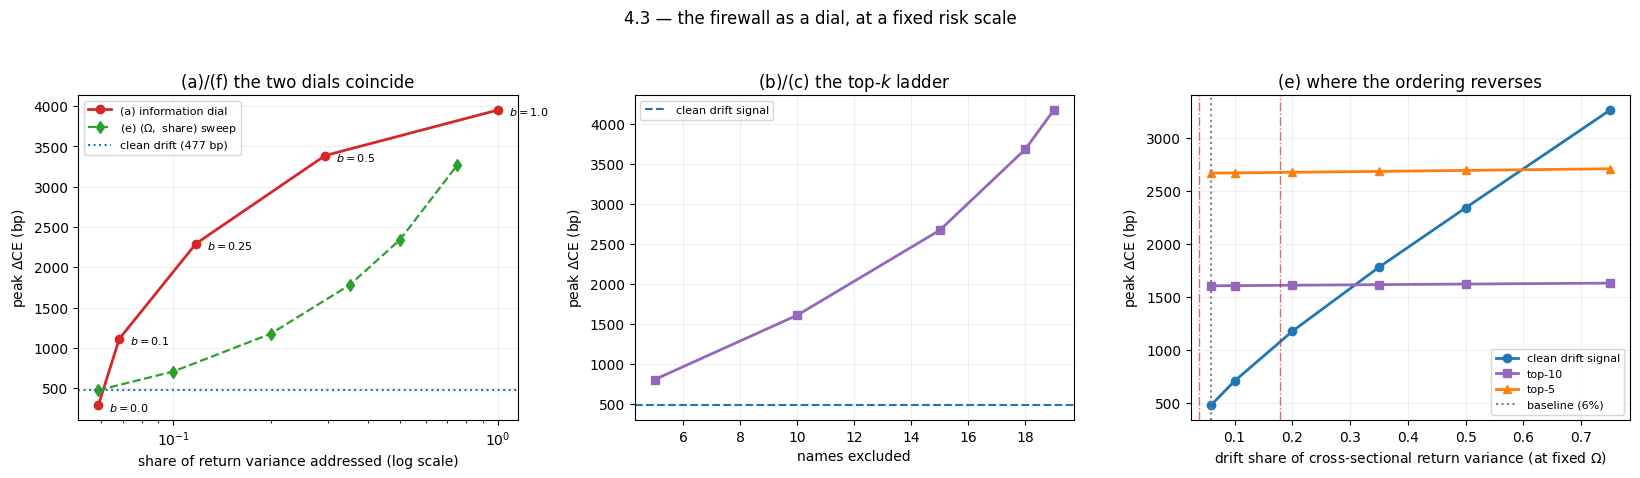

In [31]:
# ---- Experiment 4.3 ----
# (a) the information dial     (b) top-k ladder              (c) exchange rate at baseline
# (d) falsification test       (e) the (Omega, share) sweep  (f) the two dials are one dial
# (g) scaling laws and break-even       (h) the exchange rate in units of names
# (i) four market regimes
sigma_eps_base = 0.05
shock = sigma * np.sqrt(dt) * phi
drift_share = sigma_mu**2 * dt**2 / (sigma_mu**2 * dt**2 + sigma**2 * dt)
Omega_base  = np.sqrt(sigma_mu**2 * dt**2 + sigma**2 * dt)
share = lambda b: (sigma_mu**2 * dt**2 + b**2 * sigma**2 * dt) / (sigma_mu**2 * dt**2 + sigma**2 * dt)
rule = "-" * 78

# ---------------- (a) the information dial ----------------
# The signal is given a fraction b of the realised diffusion shock. This is NOT proposed as a
# purchasable signal; it is a NUMERAIRE, a unit in which any other signal can be priced. What the
# GBM calls an unpredictable shock is unpredictable relative to THE MODEL'S filtration; an analyst
# who anticipates an earnings surprise forecasts part of it. So b measures informational advantage,
# not clairvoyance. Part (f) shows this dial is the same object as the world-side dial of part (e).
b_grid   = [0.0, 0.1, 0.25, 0.5, 1.0]
res_leak = {b: best_beta(mu + b * shock + sigma_eps_base * eps0, R) for b in b_grid}
clean_pk, clean_bstar = best_beta(mu, R, grid=np.linspace(0, 200, 101))

print(f"variance budget at the baseline: drift {drift_share:.1%}, diffusion shock {1-drift_share:.1%}")
print(f"total cross-sectional spread Omega = {Omega_base:.4f}")
print(f"clean drift signal: {clean_pk:.1f} bp at beta* = {clean_bstar:.0f}\n")
print("(a) THE INFORMATION DIAL");  print(rule)
print(f"{'b':>6} {'shock seen':>11} {'b^2':>7} {'share added':>12} {'total share':>12} {'peak dCE':>10} {'beta*':>7}")
print(rule)
for b in b_grid:
    print(f"{b:>6} {b:>10.0%} {b**2:>7.3f} {b**2*(1-drift_share):>11.1%} {share(b):>12.1%} "
          f"{res_leak[b][0]:>10.1f} {res_leak[b][1]:>7.0f}")
print(rule)

# ---------------- (b) the top-k ladder ----------------
order     = np.argsort(R, axis=1)
bgrid_ind = np.linspace(0.0, 12.0, 61)
def topk_signal(order_mat, k, like):
    ind = np.zeros_like(like); np.put_along_axis(ind, order_mat[:, -k:], 1.0, axis=1); return ind

k_show = [15, 10, 5, 2, 1]
res_topk, theta_at_opt = {}, {}
for k in k_show:
    ind = topk_signal(order, k, R)
    res_topk[k] = best_beta(ind, R, grid=bgrid_ind)
    theta_at_opt[k] = theta_of(softmax_weights(ind, res_topk[k][1])).mean()

print("\n(b) TOP-k LADDER");  print(rule)
print(f"{'k':>4} {'of universe':>12} {'names excluded':>15} {'peak dCE':>10} {'x clean':>9} {'theta@opt':>10} {'theta_max':>10}")
print(rule)
for k in k_show:
    print(f"{k:>4} {k/N:>12.0%} {N-k:>15} {res_topk[k][0]:>10.1f} {res_topk[k][0]/clean_pk:>9.1f} "
          f"{theta_at_opt[k]:>10.3f} {1-np.log(k)/np.log(N):>10.3f}")
print(rule)
print("the map is long-only, so a top-k signal can only be acted on by holding the k named names;")
print("at large beta the weights converge to uniform on that set, which is why theta saturates.")

# ---------------- (c) exchange rate, baseline parameters only ----------------
ks_full = list(range(19, 0, -1))
tk_full = np.array([best_beta(topk_signal(order, k, R), R, grid=bgrid_ind)[0] for k in ks_full])
ka      = np.array(ks_full, float)
def k_equiv(v):
    return float(np.interp(v, tk_full, ka)) if v >= tk_full[0] else np.nan

print(f"\n(c) EXCHANGE RATE at the baseline drift share of {drift_share:.1%}: "
      f"what is a drift signal worth, in names excluded?")
print("    (parts (e) and (g) show how this changes as the share and the scale move)")
print(rule)
print(f"{'signal':>34} {'peak dCE':>10} {'equivalent to':>26}")
print(rule)
for lab, s_, gr in [('clean drift (sigma_eps = 0)',      mu,                                np.linspace(0,200,101)),
                    ('drift at baseline noise 0.05',     mu + 0.05*eps0,                    beta_grid),
                    ('drift + 10% of the shock',         mu + 0.10*shock + 0.05*eps0,       np.linspace(0,200,101)),
                    ('drift + 25% of the shock',         mu + 0.25*shock + 0.05*eps0,       np.linspace(0,300,151))]:
    v = best_beta(s_, R, grid=gr)[0]; ke = k_equiv(v)
    print(f"{lab:>34} {v:>10.1f} {f'top-{ke:.1f}, i.e. naming {N-ke:.1f} names to avoid':>26}")
print(rule)
d_ = np.diff(tk_full)
print(f"the ladder is convex in names excluded: about {d_.min():.0f} bp for the first few names excluded, "
      f"rising to {d_.max():.0f} bp for the last, mean {d_.mean():.0f}.")

# ---------------- (d) falsification test ----------------
rng_x  = np.random.default_rng(2026)
win    = rng_x.integers(0, N, size=n_sims)
mu_x   = np.full((n_sims, N), -0.10); mu_x[np.arange(n_sims), win] = +0.40
R_x    = np.exp((mu_x - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*phi) - 1.0
share_x = mu_x.var(axis=1).mean()*dt**2 / (mu_x.var(axis=1).mean()*dt**2 + sigma**2*dt)
order_x = np.argsort(R_x, axis=1)
clean_x = best_beta(mu_x, R_x, np.linspace(0, 60, 121))[0]
topk_x  = {k: best_beta(topk_signal(order_x, k, R_x), R_x, bgrid_ind)[0] for k in [10, 5, 2]}

print("\n(d) FALSIFICATION TEST: an extreme cross-section, built so the drift SHOULD win")
print(f"    1 name at mu = +0.40, the rest 19 at -0.10")
print(rule)
print(f"{'':<22}{'EXTREME  (drift share ' + f'{share_x:.0%})':>26}{'BASELINE  (drift share ' + f'{drift_share:.0%})':>28}")
print(f"{'signal':<22}{'dCE':>12}{'vs drift':>14}{'dCE':>14}{'vs drift':>14}")
print(rule)
print(f"{'clean drift':<22}{clean_x:>12.0f}{1.00:>14.2f}{clean_pk:>14.0f}{1.00:>14.2f}")
for k in [10, 5, 2]:
    print(f"{f'top-{k}':<22}{topk_x[k]:>12.0f}{topk_x[k]/clean_x:>14.2f}"
          f"{res_topk[k][0]:>14.0f}{res_topk[k][0]/clean_pk:>14.2f}")
print(rule)
print("'vs drift' is the signal's value divided by the clean drift signal's, so a figure below 1")
print("means the drift signal wins. At the baseline every top-k beats it; on the extreme")
print("cross-section top-10 and top-5 fall below it. The ordering reverses, so the machinery")
print("is not rigged towards outcome information.")

# ---------------- (e) the (Omega, share) sweep ----------------
# Reparameterised. (sigma_mu, sigma) are not two independent economic quantities: at dt = 1 both
# enter the log return as Gaussian shifts with the same scaling, so from returns alone only their
# sum of squares is identified. What is separately meaningful is
#     Omega = sqrt(sigma_mu^2 dt^2 + sigma^2 dt)   total cross-sectional spread   (OBSERVABLE)
#     share = sigma_mu^2 dt^2 / Omega^2            predictable fraction           (LATENT)
# Sweeping sigma_mu at fixed sigma moves both at once and so confounds information content with
# risk scale. Here Omega is held at its baseline value and only the share moves.
def lab_world(sig_mu_c, sigma_c, mu_bar_c=None, seed=42):
    """A self-contained market: its own CRN, drift dispersion and diffusion scale."""
    mb = mu_bar if mu_bar_c is None else mu_bar_c
    r  = np.random.default_rng(seed)
    m  = mb + sig_mu_c * r.standard_normal((n_sims, N))
    p  = r.standard_normal((n_sims, N))
    Rc = np.exp((m - 0.5*sigma_c**2)*dt + sigma_c*np.sqrt(dt)*p) - 1.0
    return m, Rc, np.argsort(Rc, axis=1)

def value_of(m, Rc, oc, sig_mu_c, ks=(10, 5, 2)):
    """Peak dCE for the clean drift signal and for each top-k, within one market."""
    hi = max(60.0, 6.0 / max(sig_mu_c, 1e-6))
    cl = best_beta(m, Rc, np.linspace(0, hi, 81))[0]
    tk = {k: best_beta(topk_signal(oc, k, Rc), Rc, bgrid_ind)[0] for k in ks}
    return cl, tk

print("\n(e) THE (Omega, share) SWEEP: information content at a FIXED risk scale")
print(f"    Omega held at the baseline {Omega_base:.4f}; only the predictable fraction varies")
print(rule)
print(f"{'share':>8} {'sigma_mu':>9} {'sigma':>7} {'clean drift':>12} {'top-10':>9} {'top-5':>9} {'drift/top-10':>13}")
print(rule)
share_grid = [drift_share, 0.10, 0.20, 0.35, 0.50, 0.75]
sweep = {}
for sh in share_grid:
    smu_c, sg_c = Omega_base*np.sqrt(sh), Omega_base*np.sqrt(1-sh)
    m, Rc, oc = lab_world(smu_c, sg_c)
    cl, tk = value_of(m, Rc, oc, smu_c)
    sweep[sh] = (smu_c, sg_c, cl, tk[10], tk[5])
    print(f"{sh:>8.1%} {smu_c:>9.3f} {sg_c:>7.3f} {cl:>12.0f} {tk[10]:>9.0f} {tk[5]:>9.0f} {cl/tk[10]:>13.2f}")
print(rule)
shs   = np.array(share_grid)
rat10 = np.array([sweep[s][2]/sweep[s][3] for s in share_grid])
rat5  = np.array([sweep[s][2]/sweep[s][4] for s in share_grid])
x10, x5 = np.interp(1.0, rat10, shs), np.interp(1.0, rat5, shs)
print("at constant Omega the top-k columns are FLAT to within a couple of per cent across a 13-fold")
print("change in the share: their content does not depend on it, they always name the same number of")
print("realised winners. The clean drift column is the only one that moves. This separation was")
print("hidden in the earlier version of this sweep, which raised sigma_mu at fixed sigma and so")
print("raised Omega at the same time, crediting top-k with a gain that came from the scale.")
print(f"the drift signal overtakes top-10 at a share of about {x10:.0%}, and top-5 at about {x5:.0%}.")
print(f"the same share is reached by lengthening the horizon: share = 50% at dt = sigma^2/sigma_mu^2 = "
      f"{sigma**2/sigma_mu**2:.0f} years.")

# ---------------- (f) the two dials are the same dial ----------------
# (a) raises the share the SIGNAL addresses, holding the world fixed.
# (e) raises the share the WORLD makes predictable, holding the signal clean.
# At dt = 1 and fixed Omega these are the same experiment: the cross-sectional return distribution
# is N(., Omega^2) either way and only the signal's correlation with it changes.
def b_for_share(target):
    # rho^2(b) = (s_mu^2 + b sg^2)^2 / ((s_mu^2 + b^2 sg^2)(s_mu^2 + sg^2)); solved by bisection
    f = lambda b: (sigma_mu**2 + b*sigma**2)**2 / ((sigma_mu**2 + b**2*sigma**2)*Omega_base**2) - target
    lo, hi = 0.0, 1.0
    if f(lo)*f(hi) > 0: return np.nan
    for _ in range(80):
        md = 0.5*(lo+hi)
        if f(lo)*f(md) <= 0: hi = md
        else: lo = md
    return 0.5*(lo+hi)

print("\n(f) THE TWO DIALS ARE THE SAME DIAL")
print("    (a) gives the analyst partial sight of the shock; (e) makes more of the return genuinely")
print("    drift-driven. At dt = 1 and fixed Omega the two coincide.")
print(rule)
print(f"{'target share':>13} {'(a) leakage b':>15} {'dCE':>9} {'(e) sigma_mu':>13} {'sigma':>7} {'dCE':>9} {'gap':>8}")
print(rule)
for sh in [drift_share, 0.15, 0.30, 0.50, 0.75]:
    b_ = b_for_share(sh)
    dA = best_beta(mu + b_*shock, R, np.linspace(0, 400, 81))[0]
    smu_c, sg_c = Omega_base*np.sqrt(sh), Omega_base*np.sqrt(1-sh)
    m, Rc, _ = lab_world(smu_c, sg_c)
    dB = best_beta(m, Rc, np.linspace(0, 400, 81))[0]
    print(f"{sh:>13.1%} {b_:>15.4f} {dA:>9.1f} {smu_c:>13.3f} {sg_c:>7.3f} {dB:>9.1f} {100*(dB-dA)/dA:>7.1f}%")
print(rule)
print("The two columns agree to well within Monte-Carlo error at low share and drift apart only at")
print("the top, where the Ito term -sigma^2/2 differs between the two worlds. The dial of part (a)")
print("is therefore not a firewall breach to be quarantined but a unit of account: it prices any")
print("signal in terms of how much of the shock an analyst would have to foresee to match it.")

# ---------------- (g) scaling laws and the break-even ----------------
print("\n(g) SCALING LAWS: how each signal type is paid")
print(rule)
grid_mu, grid_sg = [0.025, 0.05, 0.10, 0.20], [0.15, 0.20, 0.30, 0.40]
rows = []
for smu_c in grid_mu:
    for sg_c in grid_sg:
        m, Rc, oc = lab_world(smu_c, sg_c)
        cl, tk = value_of(m, Rc, oc, smu_c)
        rows.append((smu_c, sg_c, smu_c**2*dt**2/(smu_c**2*dt**2+sg_c**2*dt),
                     np.sqrt(smu_c**2*dt**2+sg_c**2*dt), cl, tk[10], tk[5], tk[2]))
A = np.array(rows)
X = np.c_[np.ones(len(A)), np.log(A[:, 0]), np.log(A[:, 1])]
print(f"{'signal':>14} {'exponent on sigma_mu':>21} {'exponent on sigma':>19} {'R^2':>8}")
print(rule)
for j, lab in [(4, 'clean drift'), (5, 'top-10'), (6, 'top-5'), (7, 'top-2')]:
    y_ = np.log(A[:, j]); bta = np.linalg.lstsq(X, y_, rcond=None)[0]
    print(f"{lab:>14} {bta[1]:>21.3f} {bta[2]:>19.3f} {1-((y_-X@bta).var()/y_.var()):>8.4f}")
print(rule)
print("the drift signal is PAID by sigma_mu and TAXED by sigma; the top-k signals are blind to")
print("sigma_mu (exponent ~ 0) and paid by sigma. They read realised returns, so their value scales")
print("with the total spread whatever produces it. That is the mechanism behind (e).")

y3 = np.log(A[:, 4]/A[:, 5])
X2 = np.c_[np.ones(len(A)), np.log(A[:, 2])]
X3 = np.c_[np.ones(len(A)), np.log(A[:, 2]), np.log(A[:, 3])]
b2 = np.linalg.lstsq(X2, y3, rcond=None)[0]; b3 = np.linalg.lstsq(X3, y3, rcond=None)[0]
r2 = 1-((y3-X2@b2).var()/y3.var()); r3 = 1-((y3-X3@b3).var()/y3.var())
print(f"\n    exchange rate, share only  : drift/top-10 = {np.exp(b2[0]):.2f} share^{b2[1]:.2f}"
      f"                R^2 = {r2:.3f}")
print(f"    exchange rate, + the scale : drift/top-10 = {np.exp(b3[0]):.2f} share^{b3[1]:.2f} "
      f"Omega^{b3[2]:.2f}  R^2 = {r3:.3f}")
print("    the share alone almost suffices; the residual is the CARA scale term and it is")
print("    systematic, not noise -- at equal share the drift signal fares better when Omega is small.")
print(f"\n    break-even (clean drift = top-10):")
print(rule)
print(f"{'Omega':>8} {'break-even share':>18}")
print(rule)
for Om in [0.15, 0.20, 0.30, 0.40]:
    print(f"{Om:>8.2f} {np.exp((-b3[2]*np.log(Om)-b3[0])/b3[1]):>18.1%}")
print(rule)
print("the Omega = 0.20 row is the baseline scale and reproduces the crossover found in (e).")

# ---------------- (h) the exchange rate in units of names ----------------
# Part (c) priced the drift signal against the ladder at ONE parameter set: worth about top-17.1,
# i.e. naming 2.9 names to avoid. Parts (e) and (g) showed the ladder is flat in the share while
# the drift signal is not, so that price must move. Inverting the ladder in each market turns the
# exchange rate into a function, k*(share) -- the coarse set-valued signal worth exactly what a
# clean drift signal is worth. The reported quantity is N - k*, the number of names one would have
# to be able to EXCLUDE to match it, which is the interpretable direction.
#
# Note this is a re-expression of (g), not a new fact. Setting the two scaling laws equal,
#     sigma_mu^1.45 sigma^-1.02  =  C f(k) sigma^0.75   =>   f(k*) ~ share^0.725 Omega^-0.32,
# so the exponents below are predicted in advance by the fits above.
ks_ladder = [1, 2, 3, 5, 7, 10, 13, 16, 19]
mkts_i = [(0.025, 0.20), (0.025, 0.15), (0.05, 0.30), (0.05, 0.20), (0.05, 0.15), (0.10, 0.30),
          (0.10, 0.20), (0.10, 0.15), (0.20, 0.30), (0.20, 0.20), (0.20, 0.15)]
print("\n(h) THE EXCHANGE RATE IN UNITS OF NAMES: how many names is a drift signal worth?")
print(rule)
print(f"{'sigma_mu':>9} {'sigma':>7} {'share':>8} {'Omega':>7} {'drift dCE':>11} {'k*':>7} {'names to exclude':>18}")
print(rule)
rows_i = []
for smu_c, sg_c in mkts_i:
    m_c, R_c, o_c = lab_world(smu_c, sg_c)
    lad = np.array([best_beta(topk_signal(o_c, k, R_c), R_c, bgrid_ind)[0] for k in ks_ladder])
    dr  = best_beta(m_c, R_c, np.linspace(0, max(60.0, 6.0/smu_c), 81))[0]
    sh_ = smu_c**2*dt**2/(smu_c**2*dt**2 + sg_c**2*dt); Om_ = np.sqrt(smu_c**2*dt**2 + sg_c**2*dt)
    ka  = np.array(ks_ladder, float)
    # the ladder decreases in k, so invert on the reversed arrays; NaN where the drift signal
    # falls outside the ladder's range and the exchange rate is simply not defined
    kst = float(np.interp(dr, lad[::-1], ka[::-1])) if lad.min() <= dr <= lad.max() else np.nan
    rows_i.append((smu_c, sg_c, sh_, Om_, dr, kst))
    ks_txt = f"{kst:>7.2f}" if kst == kst else f"{'--':>7}"
    ex_txt = f"{N-kst:>18.2f}" if kst == kst else f"{'not priceable':>18}"
    print(f"{smu_c:>9.3f} {sg_c:>7.2f} {sh_:>8.1%} {Om_:>7.3f} {dr:>11.0f}{ks_txt}{ex_txt}")
print(rule)

ok  = [r for r in rows_i if r[5] == r[5]]
shv = np.array([r[2] for r in ok]); Omv = np.array([r[3] for r in ok])
yv  = np.log(N - np.array([r[5] for r in ok]))
X1  = np.c_[np.ones(len(ok)), np.log(shv)]
X2  = np.c_[np.ones(len(ok)), np.log(shv), np.log(Omv)]
b1  = np.linalg.lstsq(X1, yv, rcond=None)[0]; r1 = 1 - ((yv - X1@b1).var()/yv.var())
b2  = np.linalg.lstsq(X2, yv, rcond=None)[0]; r2 = 1 - ((yv - X2@b2).var()/yv.var())
print(f"    share only : N - k* = {np.exp(b1[0]):>5.1f} share^{b1[1]:.2f}"
      f"                 R^2 = {r1:.3f}")
print(f"    + the scale: N - k* = {np.exp(b2[0]):>5.1f} share^{b2[1]:.2f} Omega^{b2[2]:.2f}"
      f"   R^2 = {r2:.3f}")
print(f"    the second variable buys {100*(r2-r1):.1f} percentage points of R^2, so the univariate law")
print(f"    is reported as the usable form; the residual is nonetheless systematic and not noise --")
print(f"    at equal share a larger Omega costs about one name, visible in the two 10% rows.")
print(f"\n{'share':>8} {'predicted N-k*':>16} {'actual':>9} {'error':>8}")
for smu_c, sg_c, sh_, Om_, dr, kst in ok:
    pr = np.exp(b1[0])*sh_**b1[1]
    print(f"{sh_:>8.1%} {pr:>16.2f} {N-kst:>9.2f} {pr-(N-kst):>8.2f}")
print(rule)
# Which market axis actually matters: the LEVEL (bull/bear) or the VOLATILITY (calm/turbulent)?
# A 2x2 answers it directly. mu_bar cannot move the share -- it is common to every name and
# cancels from the cross-sectional variance -- so the bull/bear axis can only act through the
# SCALE, because the geometric Brownian motion makes returns multiplicative while CARA scores
# absolute P&L: a bear market shrinks every gross return and with it the realised spread Omega_R.
# The calm/turbulent axis, by contrast, moves the share itself. The two effects are then compared
# on a common footing as log ratios, which is the only fair comparison between two multiplicative
# effects of very different size.
print(f"\n    LEVEL versus VOLATILITY: which market axis moves the exchange rate?")
print(rule)
print(f"{'regime':>20} {'mu_bar':>8} {'sig_mu':>7} {'sigma':>6} {'share':>7} {'Omega_R':>9} "
      f"{'k*':>7} {'names to exclude':>18}")
print(rule)
cells_h = {}
for vlab, smu_c, sg_c in [('calm', 0.07, 0.15), ('turbulent', 0.09, 0.45)]:
    for mlab, mb in [('bull', 0.24), ('bear', -0.33)]:
        m_c, R_c, o_c = lab_world(smu_c, sg_c, mu_bar_c=mb)
        lad = np.array([best_beta(topk_signal(o_c, k, R_c), R_c, bgrid_ind)[0] for k in ks_ladder])
        dr  = best_beta(m_c, R_c, np.linspace(0, max(60.0, 6.0/smu_c), 81))[0]
        ka  = np.array(ks_ladder, float)
        kst = float(np.interp(dr, lad[::-1], ka[::-1]))
        sh_ = smu_c**2*dt**2/(smu_c**2*dt**2 + sg_c**2*dt)
        cells_h[(mlab, vlab)] = N - kst
        print(f"{mlab + ', ' + vlab:>20} {mb:>+8.2f} {smu_c:>7.2f} {sg_c:>6.2f} {sh_:>7.1%} "
              f"{R_c.std(axis=1).mean():>9.3f} {kst:>7.2f} {N-kst:>18.2f}")
print(rule)
lvl = [cells_h[('bear', v)]/cells_h[('bull', v)] for v in ('calm', 'turbulent')]
vol = [cells_h[(m, 'calm')]/cells_h[(m, 'turbulent')] for m in ('bull', 'bear')]
print(f"{'LEVEL effect  (bull -> bear, share unchanged)':>52}: "
      f"x{lvl[0]:.2f} in calm, x{lvl[1]:.2f} in turbulent")
print(f"{'VOLATILITY effect  (calm -> turbulent)':>52}: "
      f"x{vol[0]:.2f} in bull, x{vol[1]:.2f} in bear")
print(f"{'ratio of the two, in log terms':>52}: "
      f"{np.mean(np.log(vol))/np.mean(np.log(lvl)):.1f}x")
print(rule)
print("The volatility axis dominates by roughly six to one. It does so because it is the only one")
print("of the two that touches the SHARE: mu_bar is common to every name, so the bull/bear move")
print("leaves the information content of the drift signal exactly intact and acts only through the")
print("realised scale, whereas calm-to-turbulent takes the share from 17.9% to 3.8%. This is the")
print("quantitative form of Experiment 4.2's result -- the market level carries no cross-sectional")
print("content -- and it is why the regimes this chapter reports are indexed by volatility rather")
print("than by direction. Note also the sign: the drift signal is worth MORE names in a bear")
print("market, because smaller absolute stakes favour it, exactly as the Omega exponent requires.")

print("Two limits. As share -> 0 the law correctly gives N - k* -> 0: a signal about nothing is")
print("worth excluding nobody. It is NOT anchored at the other end -- at share = 1 the drift signal")
print("IS the return, so k* = 1 and N - k* = 19, where the fit overshoots by about 15%. More")
print("importantly the measure DEGENERATES at low share: below roughly 2% of variance the drift")
print("signal is worth less than top-19 and the ladder cannot price it at all, as the rows above")
print("marked 'not priceable' show. The exchange rate is therefore most informative in calm markets,")
print("where sigma is small relative to sigma_mu and the drift owns enough of the variance for the")
print("answer to sit well inside the ladder; in turbulent markets it floors out and stops")
print("discriminating, which is itself the substantive finding of (e).")

# ---------------- (i) four market regimes ----------------
# mu_bar carries no INFORMATION: it is common to every name, cancels from the cross-sectional
# variance, and cannot move the share. But the GBM makes returns multiplicative while CARA is
# defined on absolute P&L, so mu_bar rescales the realised spread Omega_R and therefore enters
# through exactly the scale term identified in (g). The prediction column tests that reading.
print("\n(i) FOUR MARKET REGIMES")
print("    bull/bear sets mu_bar; calm/turbulent sets (sigma_mu, sigma) jointly, both countercyclical.")
print("    'pred' applies the exchange rate of (g) at the REALISED spread Omega_R.")
print(rule)
print(f"{'regime':>18} {'mu_bar':>7} {'sg_mu':>6} {'sigma':>6} {'share':>7} {'Omega':>7} {'Omega_R':>8} "
      f"{'drift':>7} {'top-10':>7} {'ratio':>6} {'pred':>6}")
print(rule)
regimes = [('bull, calm',      +0.24, 0.07, 0.15),
           ('bull, turbulent', +0.24, 0.09, 0.45),
           ('bear, calm',      -0.33, 0.07, 0.15),
           ('bear, turbulent', -0.33, 0.09, 0.45),
           ('BASELINE (ch.3)', mu_bar, sigma_mu, sigma)]
reg = {}
for lab, mb, smu_c, sg_c in regimes:
    m, Rc, oc = lab_world(smu_c, sg_c, mu_bar_c=mb)
    cl, tk = value_of(m, Rc, oc, smu_c)
    sh  = smu_c**2*dt**2/(smu_c**2*dt**2 + sg_c**2*dt)
    Om  = np.sqrt(smu_c**2*dt**2 + sg_c**2*dt)
    OmR = Rc.std(axis=1).mean()
    pr  = np.exp(b3[0]) * sh**b3[1] * OmR**b3[2]
    reg[lab] = (sh, Om, OmR, cl, tk[10], pr)
    print(f"{lab:>18} {mb:>+7.2f} {smu_c:>6.2f} {sg_c:>6.2f} {sh:>7.1%} {Om:>7.3f} {OmR:>8.3f} "
          f"{cl:>7.0f} {tk[10]:>7.0f} {cl/tk[10]:>6.2f} {pr:>6.2f}")
print(rule)
print("Three readings. (i) The bull/bear axis does not touch the share, so it cannot change WHICH")
print("signal is the more informative -- the ordering (drift below top-10) holds in all four cells.")
print("(ii) It does move the LEVELS, because a lower mu_bar shrinks every gross return and so shrinks")
print("the realised spread Omega_R; the effect enters entirely through the scale term of (g), which")
print("is why the 'pred' column tracks the realised ratio. (iii) All of the interesting variation is")
print("on the calm/turbulent axis: a drift signal is worth least, relative to outcome information,")
print("exactly when volatility is highest -- which is when a manager most wants it.")

# ---------------- figures ----------------
fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.6))
ax = axes[0]
ax.plot([share(b) for b in b_grid], [res_leak[b][0] for b in b_grid], 'o-', lw=2, color='tab:red',
        label='(a) information dial')
ax.plot(shs, [sweep[s][2] for s in share_grid], 'd--', lw=1.6, color='tab:green',
        label=r'(e) $(\Omega,\ \mathrm{share})$ sweep')
for b in b_grid:
    ax.annotate(fr'$b={b}$', (share(b), res_leak[b][0]), textcoords='offset points', xytext=(8,-4), fontsize=8)
ax.axhline(clean_pk, color='tab:blue', ls=':', lw=1.5, label=fr'clean drift ({clean_pk:.0f} bp)')
ax.set_xscale('log'); ax.set_xlabel('share of return variance addressed (log scale)')
ax.set_ylabel(r'peak $\Delta$CE (bp)'); ax.set_title('(a)/(f) the two dials coincide')
ax.grid(alpha=0.2); ax.legend(fontsize=8)

ax = axes[1]
ax.plot([N-k for k in k_show], [res_topk[k][0] for k in k_show], 's-', lw=2, color='tab:purple')
ax.axhline(clean_pk, color='tab:blue', ls='--', lw=1.5, label='clean drift signal')
ax.set_xlabel('names excluded'); ax.set_ylabel(r'peak $\Delta$CE (bp)')
ax.set_title(r'(b)/(c) the top-$k$ ladder'); ax.grid(alpha=0.2); ax.legend(fontsize=8)

ax = axes[2]
ax.plot(shs, [sweep[s][2] for s in share_grid], 'o-', lw=2, color='tab:blue', label='clean drift signal')
ax.plot(shs, [sweep[s][3] for s in share_grid], 's-', lw=2, color='tab:purple', label='top-10')
ax.plot(shs, [sweep[s][4] for s in share_grid], '^-', lw=2, color='tab:orange', label='top-5')
ax.axvline(drift_share, color='grey', ls=':', lw=1.5, label=f'baseline ({drift_share:.0%})')
for lab in ['bull, calm', 'bull, turbulent']:
    ax.axvline(reg[lab][0], color='tab:red', ls='-.', lw=1.0, alpha=0.7)
    ax.annotate(lab.split(',')[1].strip(), (reg[lab][0], 0), rotation=90, fontsize=7,
                color='tab:red', va='bottom', ha='right')
ax.set_xlabel(r'drift share of cross-sectional return variance (at fixed $\Omega$)')
ax.set_ylabel(r'peak $\Delta$CE (bp)'); ax.set_title(r'(e) where the ordering reverses')
ax.grid(alpha=0.2); ax.legend(fontsize=8)
plt.suptitle(r'4.3 — the firewall as a dial, at a fixed risk scale', y=1.03)
plt.tight_layout(); plt.show()

**Reading.** The variance-share claim is confirmed at the baseline, given an interpretable price, tested against a case designed to overturn it, freed from its confounding with the risk scale, and finally shown to be the same claim as the leakage dial's.

**(a) Value tracks the variance share, and the mapping is steep.** Moving from $b = 0$ to $b = 0.1$ — raising the share addressed from $5.9\%$ to $6.8\%$ — more than doubles the peak gain. The clean drift signal, which knows $\mu$ *exactly*, earns $477$ bp; a noisy signal that sees a quarter of the shock earns $2293$. Detail is not what pays; coverage of the variance is.

**(b)/(c) The exchange rate.** A clean drift signal is worth about the same as being told the identity of the top $17.1$ names — that is, naming $2.9$ names to avoid. The fractional figure is an interpolation on the top-$k$ ladder, not a claim that one can name a fraction of a name; the ladder is convex in names excluded, about $151$ bp for the first few, rising to $491$ bp for the last, mean $222$.

**(d) The falsification test passes.** On a cross-section built so the drift *should* win — one name at $\mu = +0.40$, nineteen at $-0.10$, a drift share of $23\%$ — the ordering reverses: top-10 falls to $0.41$ of the clean drift signal's value and top-5 to $0.72$, where at the baseline they stood at $3.37$ and $5.60$. The machinery is therefore not rigged towards outcome information; it reports the variance budget it is given.

**(e) At a fixed risk scale the separation is clean, and cleaner than before.** Holding $\Omega$ at its baseline $0.2062$ and moving only the share from $5.9\%$ to $75\%$, the top-10 column moves from $1604$ to $1629$ bp and top-5 from $2667$ to $2709$ — flat to within $2\%$ across a thirteen-fold change in the share. The clean drift column moves from $475$ to $3263$. This is the experiment's sharpest form, and the earlier version obscured it: raising $\sigma_\mu$ at fixed $\sigma$ raises $\Omega$ at the same time, which credited the top-$k$ signals with a gain of more than a factor of two that came from the widening spread of outcomes rather than from anything about the signal. At constant scale their content is exactly unchanged, as it should be — they always name the same number of realised winners. The drift signal overtakes top-10 at a share near $31\%$ and top-5 near $60\%$.

**(f) The two dials are one dial.** Part (a) raises the share the *signal* addresses while holding the world fixed; part (e) raises the share the *world* makes predictable while holding the signal clean. They agree to $-0.4\%$, $0.0\%$, $0.3\%$, $0.9\%$ and $1.2\%$ across the range, the residual coming from the Itô term $-\sigma^2/2$, which differs between the two worlds. This follows from the observational equivalence noted above: at $\Delta t = 1$ and fixed $\Omega$ the cross-sectional return distribution is $\mathcal{N}(\cdot,\Omega^2)$ either way, and only the signal's correlation with it changes. The consequence is a statement worth making plainly: **an analyst with partial foresight of the shock is exactly equivalent to a clean analyst in a world where more of the return is genuinely drift-driven.** The leakage dial is therefore not a firewall breach to be quarantined but a unit of account, and the caveat is that this equivalence is a $\Delta t = 1$ phenomenon — at other horizons the drift scales as $\Delta t$ and the diffusion as $\sqrt{\Delta t}$, and the two dials come apart.

**(g) The scaling laws separate the two signal types by what pays them.** On a $4 \times 4$ grid in $(\sigma_\mu, \sigma)$,
$$
\Delta\mathrm{CE}_{\text{drift}} \propto \sigma_\mu^{1.45}\,\sigma^{-1.02} \;(R^2 = 0.99),
\qquad
\Delta\mathrm{CE}_{\text{top-}k} \propto \sigma_\mu^{0.13}\,\sigma^{+0.75} \;(R^2 = 0.94).
$$
The drift signal is paid by the drift dispersion and taxed by the diffusion; the top-$k$ signals are blind to $\sigma_\mu$ — the exponent is statistically indistinguishable from zero — and paid by $\sigma$, because they read realised returns and so profit from the total spread whatever produces it. Combining the two gives the exchange rate as an equation,
$$
\frac{\Delta\mathrm{CE}_{\text{drift}}}{\Delta\mathrm{CE}_{\text{top-}10}}
\;\approx\; 1.23\;\mathrm{share}^{0.80}\;\Omega^{-0.51}, \qquad R^2 = 0.998 ,
$$
against $R^2 = 0.978$ for the share alone. The share very nearly suffices, and the residual is not noise but the CARA scale term: at equal share the drift signal fares better when the absolute stakes are smaller. Break-even against top-10 sits at $22.9\%$ of variance when $\Omega = 0.15$, $27.5\%$ at $0.20$, $35.7\%$ at $0.30$ and $43.0\%$ at $0.40$ — the second of which reproduces the crossover found independently in (e).

**(h) The exchange rate as a function.** Part (c) priced the drift signal against the ladder at one parameter set — worth about top-$17.1$, i.e. naming $2.9$ names to avoid. Parts (e) and (g) then showed why that price cannot be a constant: the ladder is flat in the share while the drift signal is not. Inverting the ladder market by market turns the price into a function. Writing $k^\star$ for the coarse set-valued signal worth exactly what a clean drift signal is worth, and reporting $N - k^\star$, the number of names one would have to be able to **exclude** to match it,
$$
N - k^\star \;\approx\; 21.9\,\cdot\,\mathrm{share}^{0.73}, \qquad R^2 = 0.98 .
$$
Adding the scale gives $N - k^\star \approx 13.3\,\mathrm{share}^{0.76}\,\Omega^{-0.38}$ at $R^2 = 0.998$, but the second variable buys under two points of $R^2$ and the univariate law is the usable form. The residual is nonetheless systematic rather than noise: at $\mathrm{share} = 10\%$ the answer is $4.80$ names when $\Omega = 0.158$ and $3.71$ when $\Omega = 0.316$, so a larger absolute spread costs about one name — the same direction, and for the same reason, as the $\Omega^{-0.51}$ term in the break-even.

The exponents are not new information. Setting the two scaling laws of (g) equal, $\sigma_\mu^{1.45}\sigma^{-1.02} = C f(k)\,\sigma^{0.75}$, and substituting $\sigma_\mu = \Omega\sqrt{\mathrm{share}}$, $\sigma = \Omega\sqrt{1-\mathrm{share}}$, predicts $f(k^\star) \sim \mathrm{share}^{0.725}\Omega^{-0.32}$ in advance of the fit, against $0.76$ and $-0.38$ measured. Part (h) is therefore (g) re-expressed in units a portfolio manager can act on, and the agreement is a consistency check on both.

**Which market axis matters.** Both fits are reported because the comparison between them is the argument, not because both are needed. Adding $\Omega$ lifts $R^2$ from $0.981$ to $0.998$ — under two points — and the univariate law's largest error across the grid is $1.04$ names in twenty. That is the practical case for carrying the share alone. The structural case is stronger, and it is that **everything which is not the share enters through a single channel.** At $\Delta t = 1$ there are exactly two economically distinct coordinates: the share, which says how much of the cross-section is predictable, and $\Omega$, which says how large the cross-section is. The first is the *information* variable, the second the *scale*, and the scale carries a small exponent because it acts only through the CARA term — at equal information a signal is worth relatively more when the absolute stakes are smaller.

That accounting is also what disposes of the bull–bear axis. Since $\bar\mu$ is common to every name it cancels from the cross-sectional variance and **cannot move the share at all**. It is not quite inert, because the geometric Brownian motion makes returns multiplicative while CARA scores absolute profit and loss, so a bear market shrinks every gross return and with it the realised spread $\Omega_R$ — but that is the *scale* channel again, the very term the univariate law drops. The $2 \times 2$ confirms both halves and, more usefully, puts numbers on the comparison:

| | calm ($\mathrm{share} = 17.9\%$) | turbulent ($\mathrm{share} = 3.8\%$) |
|---|---|---|
| bull ($\bar\mu = +0.24$) | $6.84$ names | $1.26$ names |
| bear ($\bar\mu = -0.33$) | $8.07$ names | $1.81$ names |

Reading across, the **level** effect is $\times 1.18$ in a calm market and $\times 1.43$ in a turbulent one; reading down, the **volatility** effect is $\times 5.42$ in a bull market and $\times 4.47$ in a bear one. Compared as log ratios — the only fair way to weigh two multiplicative effects of very different size — the volatility axis is worth **about six times** the level axis. This is the quantitative form of Experiment 4.2's finding that the market level carries no cross-sectional content, and it is the reason the regimes reported in this chapter are indexed by volatility rather than by direction.

Two details are worth not glossing. The level effect is larger in a turbulent market than in a calm one ($1.43$ against $1.18$), so the two axes are not quite separable. And its sign runs the intuitive way only once the mechanism is stated: the drift signal is worth **more** names in a bear market, not fewer, because the smaller absolute stakes favour it — precisely what the negative $\Omega$ exponent requires.

**Where the measure works, and where it stops.** As $\mathrm{share} \to 0$ the law correctly returns $N - k^\star \to 0$: a signal about nothing is worth excluding nobody. It is not anchored at the other end — at $\mathrm{share} = 1$ the drift signal *is* the return, so $k^\star = 1$ and $N - k^\star = 19$, where the fit overshoots by about $15\%$. The more important limitation is at the bottom. Below roughly $2\%$ of variance the drift signal is worth less than top-$19$ and the ladder cannot price it at all; the $\sigma_\mu = 0.025$, $\sigma = 0.20$ row is reported as *not priceable* for exactly this reason. The exchange rate is therefore most informative in **calm markets**, where $\sigma$ is small relative to $\sigma_\mu$ and the answer sits well inside the ladder, and it floors out in turbulent ones — which is not a defect of the measure so much as a restatement of (e): when the diffusion owns almost everything, there is very little for a drift signal to be worth.

**(i) The regimes confirm the decomposition rather than complicating it.** Across bull/bear $\times$ calm/turbulent the ordering never changes: the clean drift signal is worth less than top-10 in all four cells, at ratios $0.68$, $0.12$, $0.80$ and $0.17$. The bull/bear axis cannot move the share — $\bar\mu$ is common to every name and cancels from the cross-sectional variance — and indeed it does not change *which* signal is the more informative. What it does change is the level, because the geometric Brownian motion makes returns multiplicative while CARA is defined on absolute P&L: a bear market shrinks every gross return and with it the realised spread $\Omega_R$, from $0.204$ to $0.115$ in the calm pair. That effect enters entirely through the scale term of (g), which is why applying the fitted exchange rate at the *realised* $\Omega_R$ predicts the observed ratios to within a few points. All of the interesting variation sits on the calm/turbulent axis, and its direction is unwelcome: a drift signal is worth least, relative to outcome information, exactly when volatility is highest — which is when a manager most wants it.

**Two caveats.** The break-even shares are extrapolations of a log-linear fit estimated at $\bar\mu = 0.05$, and the top-$k$ signals read realised returns, so a large negative $\bar\mu$ moves them; the (h) table checks this directly rather than relying on the fit. Second, the regime parameters are not all citable to the same standard: the drift levels come from the bull and bear state estimates of Maheu, McCurdy and Song, the volatility *ratio* from the two-state literature, but the level of $\sigma$ and the cross-sectional dispersion $\sigma_\mu$ are modelling choices. $\sigma_\mu$ in particular is the cross-sectional standard deviation of *expected* returns, which is latent — no dispersion estimate can supply it, since the empirical measures are of realised returns and so estimate $\Omega$. This is the honest reason for treating the share as an assumed parameter with a sweep attached rather than as a calibrated one.

## Experiment 4.4 — Shape versus precision

The same underlying signal $s = \mu + \sigma_\varepsilon\varepsilon$ is now degraded in *form* rather than accuracy, per replication and cross-sectionally: **cardinal** (the values themselves), **rank-only** (the ordering $1,\dots,N$, no gaps), and **binary (median split)** (above or below the cross-sectional median). Each format is used two ways: **naively** (the coarse scores fed straight to the softmax) and through an **inference layer** that maps the format to $\mathbb{E}[\mu \mid \text{what the format reveals}]$ — for ranks, expected Gaussian order statistics (Blom's approximation) reconstruct realistic spacings, wide at the extremes and tight in the middle, without ever seeing the numbers.

One structural remark first, which the code verifies rather than assumes: for any **two-level** format such as the binary one, the naive and inference treatments are *identical* under the softmax — an affine map of a binary score is absorbed by $\beta$ and shift-invariance — so the inference layer can only matter for formats with three or more levels. The claim under test: **at matched accuracy, form matters far less than precision, and the inference layer closes most of what the naive treatment loses.** The second half of that prediction fails, and the way it fails is the experiment's main result.

Because the formats are compared at a single market, the cell that follows the Reading re-scores them in six, and asks separately whether the surprising rank result is a property of the *signal* or of the *market*.

two-level check: max |weight difference| naive vs inference sign signal = 0.00e+00



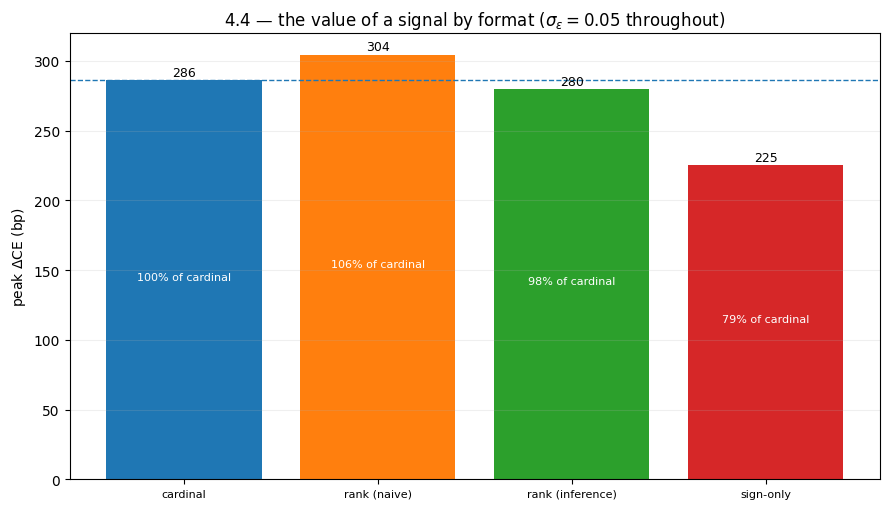

                  format  peak dCE (bp)   beta*  % of cardinal
                cardinal          286.3   21.00         100.0%
            rank (naive)          304.5    0.36         106.3%
        rank (inference)          280.0    1.50          97.8%
               sign-only          225.3   34.50          78.7%


In [32]:
# ---- Experiment 4.4 ----
s43 = mu + 0.05 * eps0
ranks = s43.argsort(axis=1).argsort(axis=1)          # 0 (lowest) .. N-1 (highest), per draw

# Blom expected order statistics of N(0,1): E[z_(r)] ~ Phi^{-1}((r - 0.375)/(N + 0.25))
blom = norm.ppf((np.arange(1, N + 1) - 0.375) / (N + 0.25))

formats = {}
formats['cardinal']       = s43
formats['rank (naive)']   = ranks.astype(float)               # equal spacing
formats['rank (inference)'] = blom[ranks]                     # order-statistic spacing
formats['binary (median split)'] = (ranks >= N // 2).astype(float)      # above/below the cross-sectional median

# two-level invariance check: inference levels for the sign format give identical weights
lvl_hi, lvl_lo = blom[N//2:].mean(), blom[:N//2].mean()
sign_inf = np.where(formats['binary (median split)'] > 0, lvl_hi, lvl_lo)
w_a = softmax_weights(formats['binary (median split)'], 6.0)
# beta must be rescaled by the level gap; shift is absorbed automatically
w_b = softmax_weights(sign_inf, 6.0 / (lvl_hi - lvl_lo))
print(f"two-level check: max |weight difference| naive vs inference binary signal = "
      f"{np.abs(w_a - w_b).max():.2e}\n")

bg43 = {'cardinal': beta_grid, 'rank (naive)': np.linspace(0, 1.2, 61),
        'rank (inference)': np.linspace(0, 6, 61), 'binary (median split)': np.linspace(0, 40, 81)}
res43 = {name: best_beta(sig, R, grid=bg43[name]) for name, sig in formats.items()}

names = list(formats)
fig, ax = plt.subplots(figsize=(9, 5.2))
vals = [res43[n][0] for n in names]
bars = ax.bar(range(len(names)), vals,
              color=['tab:blue', 'tab:orange', 'tab:green', 'tab:red'])
ax.axhline(res43['cardinal'][0], color='tab:blue', ls='--', lw=1)
for i, n in enumerate(names):
    ax.annotate(f"{vals[i]:.0f}", (i, vals[i] + 3), ha='center', fontsize=9)
    ax.annotate(f"{vals[i]/vals[0]:.0%} of cardinal", (i, vals[i] / 2), ha='center',
                fontsize=8, color='white')
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, fontsize=8)
ax.set_ylabel(r'peak $\Delta$CE (bp)')
ax.set_title(r'4.4 — the value of a signal by format ($\sigma_\varepsilon = 0.05$ throughout)')
ax.grid(axis='y', alpha=0.2)
plt.tight_layout(); plt.show()

print(f"{'format':>26} {'peak dCE (bp)':>14} {'beta*':>7} {'% of cardinal':>14}")
for n in names:
    print(f"{n:>26} {res43[n][0]:>14.1f} {res43[n][1]:>7.2f} {res43[n][0]/res43['cardinal'][0]:>14.1%}")

**Reading.** Form matters far less than precision — and where it matters, the sign is not the expected one. Rank-only retains $106\%$ of the cardinal value and binary (median split) $79\%$: even one bit per name recovers most of the cardinal signal's worth. But the striking entries are the two rank rows. The naive rank signal — equal spacing, no magnitudes — *beats* the cardinal signal ($305$ vs $286$ bp), while the inference-layer version, which faithfully reconstructs Gaussian spacings from the ranks, gives the advantage back ($280$ bp $\approx$ cardinal).

**The mechanism is not what it first appears.** The natural reading is that ranking censors the noisy tails of the *signal*: at $\sigma_\varepsilon = 0.05$ half the variance of an extreme score is noise, the softmax tilts hardest exactly there, and turning the largest score into "first of twenty" acts as an implicit robust shrinkage. That explanation is testable — it predicts the advantage should disappear as the signal is cleaned — and the following cell shows it fails. At $\sigma_\varepsilon = 0$, with a signal that reports the true drift *exactly*, ranks still win by $5\%$. There is no signal noise left to censor, so signal noise cannot be the cause.

What ranking actually censors is the **diffusion**. The cardinal signal reports, correctly, that a name's drift sits three standard deviations above the cross-section. Acting on that proportionally is nonetheless over-confident, because the drift owns only $5.9\%$ of what separates realised returns: the extreme *score* is accurate and the extreme *tilt* it invites is not. Ranking caps the tilt at "first of twenty" whatever the magnitude, which is the correct robustness against a return the signal only partly explains, and the Blom reconstruction removes the cap, restoring both the spacings and the over-confidence. Fidelity to the format is not fidelity to the truth. The governing quantity is therefore the variance share of Experiment 4.3 rather than the signal-to-noise ratio $\kappa$ — and the next cell shows the advantage decaying monotonically in the share while remaining, across the whole region this thesis studies, positive.

Two clauses of the stylised fact survive unchanged. *Precision dominates form*: all formats deliver $79$–$106\%$ here, and $58$–$107\%$ across the markets of the following cell. And *the inference layer is only needed for formats with three or more levels* — for binary formats it is provably absorbed by $\beta$, verified here to machine precision. The third clause is the one that needed restating: coarseness outperforms detail not when the detail is noisy, but when the detail is **more precise than the return it is trying to predict**.

In [33]:
# ---- Experiment 4.4, robustness: does the format ordering depend on the market? ----
# The formats are re-scored in six markets. sigma_eps is tied to sigma_mu so that kappa = 0.5 in
# every cell -- the analyst's SKILL is held constant and only the MARKET moves, which is the
# comparison that isolates the regime effect. One consequence is worth noting: with sigma_eps =
# sigma_mu the score is s = mu_bar + sigma_mu(z + eps), so its RANKS are identical in every cell.
# The rank, inference and sign formats therefore carry literally the same information throughout,
# and any movement in their columns comes from the market alone, not from the signal.
fmt_names = ['cardinal', 'rank (naive)', 'rank (inference)', 'binary (median split)']
print("(a) FORMAT VALUE ACROSS MARKET REGIMES")
print("      (sigma_eps = sigma_mu, so kappa = 0.5 in every cell)")
print(rule)
print(f"{'sig_mu':>7} {'sigma':>6} {'share':>7} | {'cardinal':>9} {'rank naive':>11} {'rank infer':>11} "
      f"{'binary':>10} | {'naive':>7} {'infer':>7} {'binary':>8}")
print(rule)
res44r = []
for smu_c in [0.05, 0.10]:
    for sg_c in [0.15, 0.20, 0.30]:
        r_ = np.random.default_rng(42)
        mu_c   = mu_bar + smu_c*r_.standard_normal((n_sims, N))
        eps_c  = r_.standard_normal((n_sims, N)); phi_c = r_.standard_normal((n_sims, N))
        R_c    = np.exp((mu_c - 0.5*sg_c**2)*dt + sg_c*np.sqrt(dt)*phi_c) - 1.0
        s_c    = mu_c + smu_c*eps_c
        rk_c   = s_c.argsort(axis=1).argsort(axis=1)
        f_c = {'cardinal':        (s_c,                            np.linspace(0, max(120.0, 6.0/smu_c), 121)),
               'rank (naive)':    (rk_c.astype(float),             np.linspace(0, 1.2, 61)),
               'rank (inference)':(blom[rk_c],                     np.linspace(0, 6, 61)),
               'binary (median split)': ((rk_c >= N//2).astype(float), np.linspace(0, 40, 81))}
        v = {k: best_beta(sig, R_c, grid=g)[0] for k, (sig, g) in f_c.items()}
        sh_ = smu_c**2*dt**2/(smu_c**2*dt**2 + sg_c**2*dt)
        res44r.append((smu_c, sg_c, sh_, v))
        print(f"{smu_c:>7.2f} {sg_c:>6.2f} {sh_:>7.1%} | {v['cardinal']:>9.1f} {v['rank (naive)']:>11.1f} "
              f"{v['rank (inference)']:>11.1f} {v['binary (median split)']:>10.1f} | "
              f"{v['rank (naive)']/v['cardinal']:>7.0%} {v['rank (inference)']/v['cardinal']:>7.0%} "
              f"{v['binary (median split)']/v['cardinal']:>8.0%}")
print(rule)
nn = len(res44r)
print(f"orderings:  rank (naive) >= cardinal in "
      f"{sum(v['rank (naive)'] >= v['cardinal'] for _,_,_,v in res44r)}/{nn} markets;  "
      f"rank (inference) < cardinal in {sum(v['rank (inference)'] < v['cardinal'] for _,_,_,v in res44r)}/{nn};  "
      f"binary < cardinal in {sum(v['binary (median split)'] < v['cardinal'] for _,_,_,v in res44r)}/{nn}.")
for k in fmt_names[1:]:
    rr = np.array([v[k]/v['cardinal'] for _,_,_,v in res44r])
    print(f"{k:>22} as a share of cardinal: min {rr.min():.0%}  max {rr.max():.0%}  mean {rr.mean():.0%}")
shv = np.array([s for _,_,s,_ in res44r])
for k in fmt_names[1:]:
    rr = np.array([v[k]/v['cardinal'] for _,_,_,v in res44r])
    print(f"{k:>22} vs the drift share: correlation {np.corrcoef(shv, rr)[0,1]:>+6.2f}")
print(rule)
print("The two rank rows are flat and the sign row is not. Coarsening to a binary split costs 14% of")
print("the cardinal signal's value where the drift owns 2.7% of the variance and 42% where it owns")
print("30.8%: detail is worth keeping only when there is something in it. The rank result is the")
print("robust one -- naive ranks match or beat the cardinal signal in every market -- and its margin")
print("narrows as the share rises. Part (b) asks what drives that, and the answer is not the")
print("one the baseline Reading originally proposed.")

# ---- (b) what governs the rank advantage: the signal, or the market? ----
# The mechanism proposed at the baseline was that ranking censors the noisy tails of the SIGNAL.
# That is testable -- it predicts the advantage should vanish as the signal is cleaned -- and it
# fails: at sigma_eps = 0 the signal is exact and ranks still win. The grid below separates the
# two candidate drivers by moving them independently: the drift share across rows (sigma is held
# at 0.20 and sigma_mu solved for, so that Omega is not confounded with the share), and the signal
# quality kappa across columns.
print("\n(b) IS THE RANK ADVANTAGE ABOUT THE SIGNAL OR ABOUT THE MARKET?")
print("    rank (naive) as a percentage of cardinal; sigma = 0.20 throughout")
print(rule)
print(f"{'share':>8} {'sigma_mu':>9} |" + "".join(f"{f'kappa={k}':>11}" for k in [1.0, 0.75, 0.5, 0.25]))
print(rule)
for sh_ in [0.059, 0.10, 0.15, 0.20, 0.308, 0.45, 0.64]:
    sg_c = 0.20; smu_c = sg_c*np.sqrt(sh_/(1.0-sh_))
    row = []
    for kap in [1.0, 0.75, 0.5, 0.25]:
        seps = 0.0 if kap >= 1.0 else smu_c*np.sqrt((1.0-kap)/kap)
        r_ = np.random.default_rng(42)
        mu_c = mu_bar + smu_c*r_.standard_normal((n_sims, N))
        e_c  = r_.standard_normal((n_sims, N)); p_c = r_.standard_normal((n_sims, N))
        R_c  = np.exp((mu_c - 0.5*sg_c**2)*dt + sg_c*np.sqrt(dt)*p_c) - 1.0
        s_c  = mu_c + seps*e_c; rk_c = s_c.argsort(axis=1).argsort(axis=1)
        c_ = best_beta(s_c,  R_c, np.linspace(0, max(400.0, 8.0/max(smu_c, seps, 1e-9)), 161))[0]
        n_ = best_beta(rk_c.astype(float), R_c, np.linspace(0, 4.0, 121))[0]
        row.append(n_/c_)
    print(f"{sh_:>8.1%} {smu_c:>9.3f} |" + "".join(f"{x:>10.0%} " for x in row))
print(rule)
print("Two readings, and the first refutes the original mechanism outright. Down the kappa = 1")
print("column the signal is EXACT -- there is no signal noise to censor -- and ranks still win at")
print("every share below 45%. Whatever ranking is protecting against, it is not the signal's own")
print("error. Across the columns the advantage WIDENS as the signal degrades, so signal noise is a")
print("secondary contributor rather than the cause.")
print()
print("What ranking censors is the DIFFUSION. A cardinal score reporting a three-standard-deviation")
print("drift is perfectly accurate; the three-standard-deviation tilt it invites is not, because the")
print("drift explains only a small part of what moves realised returns. Ranking caps the tilt at")
print("'first of twenty' whatever the magnitude. Accordingly the advantage decays monotonically in")
print("the share -- from 105% at 5.9% to 98% at 64% when the signal is clean -- and cardinal")
print("overtakes only in the top-right corner of the table: a near-perfect signal in a market where")
print("the drift owns a third to a half of the cross-sectional variance, and then by one or two")
print("points. Across the whole region this thesis studies, ranks weakly dominate.")
print()
print("A caution on reading a threshold off this table. The crossover is NOT a clean function of the")
print("share alone: sweeping sigma_mu and sigma together, so that Omega moves as well, puts it near")
print("30% instead, because the scale enters as it does everywhere else in this chapter. The robust")
print("statement is the ORDERING and its direction of travel, not a critical value.")


(a) FORMAT VALUE ACROSS MARKET REGIMES
      (sigma_eps = sigma_mu, so kappa = 0.5 in every cell)
------------------------------------------------------------------------------
 sig_mu  sigma   share |  cardinal  rank naive  rank infer  sign-only |   naive   infer    sign
------------------------------------------------------------------------------
   0.05   0.15   10.0% |     373.5       385.5       360.3      251.0 |    103%     96%     67%
   0.05   0.20    5.9% |     286.3       304.5       280.0      225.3 |    106%     98%     79%
   0.05   0.30    2.7% |     177.9       186.5       173.6      153.0 |    105%     98%     86%
   0.10   0.15   30.8% |     902.6       903.3       862.4      525.4 |    100%     96%     58%
   0.10   0.20   20.0% |     743.5       766.3       716.9      496.9 |    103%     96%     67%
   0.10   0.30   10.0% |     506.5       540.1       497.0      416.9 |    107%     98%     82%
------------------------------------------------------------------------

**Reading (robustness).** The cell does two things: it tests whether the format ordering survives a change of market, and — through part (b) — it corrects the mechanism the baseline Reading first proposed.

**(a) The orderings hold; one magnitude does not.** Naive ranks match or beat the cardinal signal in **6 of 6** markets, at $100$–$107\%$ with a mean of $104\%$, and the Blom-reconstructed version sits below cardinal in **6 of 6**, at $96$–$98\%$. Both halves of the experiment's most surprising finding are therefore robust. What is not robust is the cost of binary coarsening: binary (median split) ranges from $58\%$ to $86\%$ of the cardinal value against the $79\%$ measured at the baseline, and the variation is ordered by the drift share (correlation $-0.88$), not scattered. Coarsening costs $14\%$ where the drift owns $2.7\%$ of the cross-sectional variance and $42\%$ where it owns $30.8\%$. **Detail is worth keeping only when there is something in it.**

**(b) The rank advantage is a fact about the market, not about the signal.** The grid moves the two candidate drivers independently: the share down the rows, with $\sigma$ held at $0.20$ so that $\Omega$ is not confounded with it, and the signal quality $\kappa$ across the columns. Down the $\kappa = 1$ column the signal is *exact*, leaving no signal noise to censor, and ranks still match or beat cardinal at every share up to $30.8\%$ — which refutes the shrinkage explanation outright. Across the columns the advantage *widens* as the signal degrades ($105\% \to 107\%$ at the baseline share), so signal noise contributes but is not the cause.

What ranking censors is the **diffusion**, and the evidence is the monotone decay down each column: $105\%$ at a share of $5.9\%$ falling to $98\%$ at $64\%$ when the signal is clean. A cardinal score reporting a three-standard-deviation drift is accurate; the three-standard-deviation tilt it invites is not, while the drift explains only a small part of realised returns. Once the drift owns a third to a half of the cross-sectional variance its extremes are genuinely predictive, and censoring them begins to cost.

**Two cautions on how to state this.** First, cardinal overtakes ranks only in the top-right corner of the grid — a near-perfect signal in a market where the drift owns $45\%$ or more — and then by one or two points. Across the entire region this thesis studies, **ranks weakly dominate**, and the baseline at $\mathrm{share} = 5.9\%$, $\kappa = 0.5$ sits at $106\%$, nowhere near the boundary. Second, the crossover is *not* a clean function of the share alone. Sweeping $\sigma_\mu$ and $\sigma$ together, so that $\Omega$ moves as well, relocates it to roughly $30\%$, because the scale enters here as it does everywhere else in this chapter. The defensible claim is the ordering and its direction of travel, not a critical value.

**What this means for the chapter's claim.** The question "is the signal weak?" is the wrong question — at $\kappa = 1$ the signal is exact and ranks still win. The right question is whether the *market* is one the signal can explain. This also dissolves an apparent tension with Experiment 4.3. That experiment says the value available scales with the share; this one says the *format* required to capture that value scales with the same share. When the drift owns little, ordering is all there is to know and the reported magnitudes are over-precise; when it owns much, the magnitudes carry information and discarding them is expensive. One quantity governs both, and the two experiments are the same statement approached from opposite sides.

The corollary worth stating carefully is that the dispersion of the drifts is *not* irrelevant — $\sigma_\mu$ determines the share and therefore everything else. What is close to irrelevant, in the low-share regime this thesis studies, is the numerical dispersion of the **reported scores**. The truth's dispersion is decisive; the signal's arithmetic is not.

**A note on the design.** Tying $\sigma_\varepsilon$ to $\sigma_\mu$ in part (a) holds $\kappa = 0.5$ fixed, so the analyst's skill is constant and only the market moves. This has a useful side effect: the score is $s = \bar\mu + \sigma_\mu(z + \varepsilon)$, whose *ranks* are identical in every cell. The rank, inference and sign columns therefore carry literally the same information in all six markets, and every movement in them is attributable to the market rather than to the signal. The cardinal column is the exception, since its values, not merely their order, scale with $\sigma_\mu$.

## Experiment 4.5 — Incremental precision and the sign flip

Two drift signals now speak about the same cross-section,
$$
s_1 = \mu + n_1, \qquad s_2 = \mu + n_2, \qquad
n_1 = \sigma_1 e_1, \quad n_2 = \sigma_2\big(\rho e_1 + \sqrt{1-\rho^2}\, e_2\big),
$$
with $\sigma_1 = 0.05 < \sigma_2 = 0.10$ and noise correlation $\rho$: think of two analysts of unequal skill reading partly the same sources. They are combined additively — the rule the combination axioms of Chapter 4 select — as $s(\lambda) = (1-\lambda)\, s_1 + \lambda\, s_2$ fed to the softmax, with $\beta$ re-optimised at every $\lambda$ so the loading question is separated from the strength question.

The claim: **a loading should reflect a signal's incremental information given the others, not its standalone quality.** The Gaussian benchmark makes it quantitative. The posterior-mean loadings solve a $2\times2$ GLS problem, and what they do as $\rho$ grows is not what intuition suggests: the *stronger* signal's loading **rises**, from $0.44$ at $\rho = 0$ to $1.02$ at $\rho = 0.9$ — past one, so it is levered — while the weaker signal's falls through zero to $-0.37$. Once $\rho > \sigma_1/\sigma_2 = 0.5$ the dominated signal's loading is negative: $s_2$ is used to cancel the noise it shares with $s_1$, a hedge rather than a view. Their sum, which is the overall shrinkage applied to the pair, is **non-monotone** — it falls to a minimum of $0.50$ exactly at the flip point and then rises to $0.65$, because a pair of highly correlated analysts, correctly combined, is collectively *more* trustworthy than a pair of independent ones. The naive alternative — weight each signal by its own reliability $\kappa_k$, ignoring the overlap — predicts a positive, $\rho$-independent loading of $0.29$. The simulation locates the CE-optimal $\lambda^\star(\rho)$ and prices the naive rule's error.

A note on normalisation. The simulation combines the signals as $s(\lambda) = (1-\lambda)s_1 + \lambda s_2$, whose coefficients sum to one, whereas the raw posterior loadings sum to between $0.50$ and $0.65$. The two are compared on the *share* $\lambda$ rather than on the raw loadings because the softmax is scale-covariant: any common rescaling of the score is absorbed by $\beta$, which is re-optimised at every $\lambda$. The overall shrinkage is therefore invisible to this map, and only the split between the two analysts is identified.


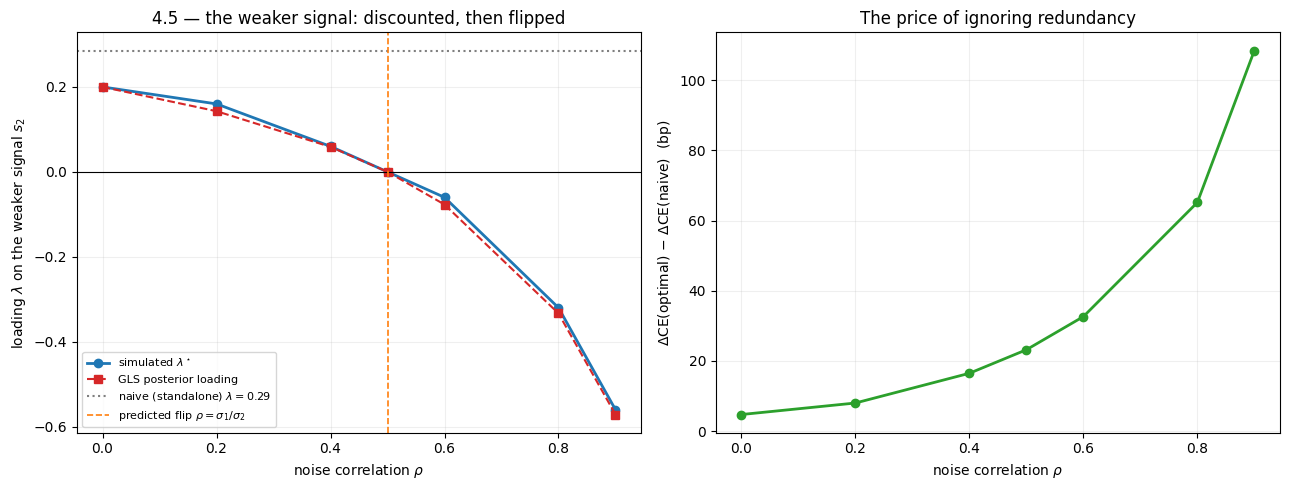

kappa_1 = 0.50, kappa_2 = 0.20; naive loading = 0.29

   rho  lambda*  GLS pred  peak dCE  naive dCE  gap (bp)
   0.0     0.20      0.20     310.8      306.0       4.7
   0.2     0.16      0.14     296.2      288.2       8.0
   0.4     0.06      0.06     287.9      271.4      16.5
   0.5     0.00      0.00     286.3      263.1      23.2
   0.6    -0.06     -0.08     287.5      254.9      32.6
   0.8    -0.32     -0.33     307.5      242.3      65.2
   0.9    -0.56     -0.57     345.3      236.8     108.5


In [16]:
# ---- Experiment 4.5 ----
sig1, sig2 = 0.05, 0.10
rho_grid  = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 0.9]
lam_grid  = np.linspace(-0.6, 1.0, 81)     # step 0.02, fine enough not to quantise lambda*
bg_coarse = np.linspace(0.0, 120.0, 31)

def gls_lambda(rho):
    # posterior-mean loadings on (s1 - mu_bar, s2 - mu_bar), normalised to sum to one
    Cn = np.array([[sig1**2, rho*sig1*sig2], [rho*sig1*sig2, sig2**2]])
    S  = sigma_mu**2 * np.ones((2, 2)) + Cn
    lam = sigma_mu**2 * np.linalg.solve(S, np.ones(2))
    return lam[1] / lam.sum()          # loading share of the weaker signal s2

kap1 = sigma_mu**2 / (sigma_mu**2 + sig1**2)
kap2 = sigma_mu**2 / (sigma_mu**2 + sig2**2)
lam_naive = kap2 / (kap1 + kap2)       # standalone-quality weighting, rho-blind

res42 = {}
for rho in rho_grid:
    s1 = mu + sig1 * eps0
    s2 = mu + sig2 * (rho * eps0 + np.sqrt(1 - rho**2) * e2_raw)
    curve = [best_beta((1 - lam) * s1 + lam * s2, R, grid=bg_coarse) for lam in lam_grid]
    peaks = np.array([c[0] for c in curve])
    k_opt = int(np.argmax(peaks))
    pk_naive, _ = best_beta((1 - lam_naive) * s1 + lam_naive * s2, R, grid=bg_coarse)
    res42[rho] = (lam_grid[k_opt], peaks[k_opt], pk_naive, peaks)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.plot(rho_grid, [res42[r][0] for r in rho_grid], 'o-', lw=2, label=r'simulated $\lambda^\star$')
ax.plot(rho_grid, [gls_lambda(r) for r in rho_grid], 's--', lw=1.5, color='tab:red',
        label='GLS posterior loading')
ax.axhline(lam_naive, color='tab:grey', ls=':', lw=1.5,
           label=fr'naive (standalone) $\lambda = {lam_naive:.2f}$')
ax.axhline(0, color='black', lw=0.8)
ax.axvline(sig1 / sig2, color='tab:orange', ls='--', lw=1.2,
           label=r'predicted flip $\rho = \sigma_1/\sigma_2$')
ax.set_xlabel(r'noise correlation $\rho$')
ax.set_ylabel(r'loading $\lambda$ on the weaker signal $s_2$')
ax.set_title(r'4.5 — the weaker signal: discounted, then flipped')
ax.grid(alpha=0.2); ax.legend(fontsize=8)

ax = axes[1]
gap = [res42[r][1] - res42[r][2] for r in rho_grid]
ax.plot(rho_grid, gap, 'o-', lw=2, color='tab:green')
ax.set_xlabel(r'noise correlation $\rho$')
ax.set_ylabel(r'$\Delta$CE(optimal) $-$ $\Delta$CE(naive)  (bp)')
ax.set_title('The price of ignoring redundancy')
ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

print(f"kappa_1 = {kap1:.2f}, kappa_2 = {kap2:.2f}; naive loading = {lam_naive:.2f}\n")
print(f"{'rho':>6} {'lambda*':>8} {'GLS pred':>9} {'peak dCE':>9} {'naive dCE':>10} {'gap (bp)':>9}")
for r in rho_grid:
    print(f"{r:>6} {res42[r][0]:>8.2f} {gls_lambda(r):>9.2f} {res42[r][1]:>9.1f} "
          f"{res42[r][2]:>10.1f} {res42[r][1]-res42[r][2]:>9.1f}")

**Reading.** The incremental-precision claim is confirmed in detail. On a $\lambda$ grid of width $0.02$, the simulated $\lambda^\star(\rho)$ tracks the GLS posterior loading to within one or two grid steps at every point ($0.20$ vs $0.20$; $0.16$ vs $0.14$; $0.06$ vs $0.06$; $0.00$ vs $0.00$; $-0.06$ vs $-0.08$; $-0.32$ vs $-0.33$; $-0.56$ vs $-0.57$), and the **sign flip happens where the theory says it should**: past $\rho = 0.5$ the weaker signal's loading turns negative — it is held as a hedge on the noise it shares with the stronger signal, not as a view. The naive rule, which weights each signal by its standalone reliability and cannot see the overlap, is priced by the widening gap: negligible at $\rho = 0$ ($5$ bp), $23$ bp at the threshold, $108$ bp at $\rho = 0.9$.

Two consistency checks fall out unprompted. At $\rho = 0.5$ the peak equals the single-signal baseline ($286$ bp) exactly: at the flip point the weaker signal contributes precisely nothing, as it should. And the peak is **non-monotone in $\rho$** — it falls to that minimum and then *rises* to $345$ bp at $\rho = 0.9$ — because strong redundancy is itself exploitable: when the two analysts' errors are almost perfectly correlated, shorting one view against the other cancels the shared noise and distils something closer to the truth than either signal alone. Redundancy degrades a naive combiner and *feeds* an optimal one. That the additive rule with signed loadings captures all of this is the multi-signal case for the Chapter 4 axioms: precision-weighting, extended to signed incremental precision, is what conditioning does — Experiment 3.2's ``strength is precision'' was the one-signal special case.

**This experiment needs no regime study, and the reason is a proof rather than a sweep.** Write the posterior precision as $S = \sigma_\mu^2 J + C$, with $J$ the all-ones matrix and $C$ the noise covariance of the two signals. Solving $S v = \mathbf{1}$ gives
$$
C v \;=\; \big(1 - \sigma_\mu^2 \textstyle\sum_i v_i\big)\,\mathbf{1},
$$
so $v \propto C^{-1}\mathbf{1}$: the prior variance enters only through a scalar that cancels when the loadings are normalised. Since
$$
C \;=\; \begin{pmatrix} \sigma_1^2 & \rho\,\sigma_1\sigma_2 \\ \rho\,\sigma_1\sigma_2 & \sigma_2^2 \end{pmatrix}
$$
contains no market parameter at all, $\lambda^\star(\rho)$ and the flip condition $\rho > \sigma_1/\sigma_2$ are functions of the *signal* covariance alone. Neither the drift dispersion, the diffusion, nor the market level can move them. Re-running the simulation at $(\sigma_\mu, \sigma) = (0.05, 0.20)$, $(0.05, 0.15)$ and $(0.10, 0.30)$ returns $\lambda^\star = 0.20, 0.00, -0.56$ at $\rho = 0, 0.5, 0.9$ in all three, identical to grid resolution — as it must be.

What the market *does* move is the levels: the peak $\Delta$CE and the naive-rule gap are basis-point quantities and scale with the market like everything else in this chapter. The claim under test is the loading curve, and that is invariant. This is a stronger statement than a robustness sweep could supply: a sweep shows a result did not happen to move, whereas the algebra shows it cannot.

## Experiment 4.6 — Recovery under noise

Chapter 1 promised that classical portfolios would appear as special cases of the map. With clean inputs that promise is exact for the combination map ($\alpha = 1$ is plug-in mean–variance) and structural for the softmax (a target with short positions is not on the family at all). This experiment prices the promise under *noisy* inputs, and asks two questions that are usually run together and should not be: how closely can each map **mimic** the classical framework, and what does mimicking it **cost**.

**Design.** One cross-section $(\mu_i, \sigma_i)$ is drawn once and frozen, so the classical targets are fixed and all randomness comes from the investor's lens. Three targets are built from the *true* parameters: the plug-in tangency $w_{\mathrm{tan}} \propto \Sigma^{-1}\mu$, which carries short positions; its **projection onto the simplex** $w_{\mathrm{lo}}$, which is the fair target for a long-only map; and the global minimum-variance portfolio $w_{\mathrm{gmv}} \propto \Sigma^{-1}\mathbf{1}$, which is long-only already. The object of study is the recovery surface $D = \mathbb{E}\lVert w - w^\ast \rVert_1$ — the $L_1$ norm because it is exactly twice the turnover needed to trade from the map's portfolio to the target — and its valley.

**Both inputs are noised.** The investor sees a drift signal $s = \mu + \sigma_\varepsilon\varepsilon$ and a volatility signal $\hat\sigma_i = \sigma_i \exp(\nu\eta_i - \nu^2/2)$, and the grid runs over both. This matters because the two maps consume the two inputs differently: the combination map divides by $\hat\sigma^2$ and is therefore exposed to $\nu$, while the softmax's score contains no volatility term at all and is exposed only to $\sigma_\varepsilon$. Holding $\hat\sigma = \sigma$, as a drift-only ladder implicitly does, hands the combination map an oracle input its competitor never receives.

Three structural anchors. First, a **bias–variance decomposition**: strength reduces bias towards the target but amplifies lens noise into weight dispersion, so the recovering strength is interior for noisy signals — the distance objective reproduces an interior optimum with bias–variance replacing risk–return. Second, for the combination map in $L_2$ the objective is an exact quadratic in $\alpha$, so the recovering strength has a closed form. Third, the softmax's clean-signal distance is a positive **structural floor**, and the long-only projection lets that floor be *decomposed* rather than merely reported: the distance to $w_{\mathrm{lo}}$ measures how badly an exponential in $\mu$ fits a linear function of $\mu/\sigma^2$, and the remainder measures what the missing short positions cost.

Finally, the **recovery–optimality tension**. The strength that best mimics a classical portfolio is not the strength that maximises utility, and the gap is not an artefact of noise — a fully invested CARA investor wants more risk than the normalised tangency point supplies, and can only obtain it by tilting past it. The certainty-equivalent panel prices three portfolios side by side: the oracle tangency portfolio, the **plug-in** portfolio a practitioner actually holds ($\alpha = 1$ with noisy inputs), and the map at its own optimum.

In [ ]:
# ---- Experiment 4.6: recovery under noisy drift AND noisy volatility ----
# (a) one frozen cross-section and its three targets
# (b) the softmax's structural floor, decomposed into shape and shorting
# (c) recovery surfaces over the two-dimensional noise grid
# (d) the certainty-equivalent horse race
rng_fc = np.random.default_rng(4646)
mu_fc  = mu_bar + sigma_mu * rng_fc.standard_normal(N)
sig_fc = np.clip(0.20 + 0.05 * rng_fc.standard_normal(N), 0.05, None)
eta46  = rng_fc.standard_normal((n_sims, N))          # volatility-signal noise
R_fc   = np.exp((mu_fc - 0.5 * sig_fc**2) * dt + sig_fc * np.sqrt(dt) * phi) - 1.0

# --- (a) targets, all built from the TRUE parameters ---
w_tan = mu_fc / sig_fc**2; w_tan /= w_tan.sum()       # plug-in tangency: long-short
w_lo  = proj_simplex(w_tan[None, :])[0]               # the same target, projected long-only
w_gmv = 1.0 / sig_fc**2;   w_gmv /= w_gmv.sum()       # GMV: long-only already
print(f"(a) frozen cross-section: {int((mu_fc < 0).sum())} of {N} drifts negative; "
      f"tangency shorts {int((w_tan < 0).sum())} names (min weight {w_tan.min():.3f})")
print(f"    long-only projection of the tangency target differs from it by "
      f"L1 = {np.abs(w_lo - w_tan).sum():.3f}; GMV min weight {w_gmv.min():.3f}\n")

# --- (b) the floor, decomposed ---
# The softmax family {w propto exp(beta*mu)} is a ONE-DIMENSIONAL curve through the simplex; the
# target is a point in it. Two separate things keep them apart, and only one is about shorting.
bfine = np.linspace(0, 400, 801)
fl_ls = min(np.abs(softmax_weights(mu_fc[None, :], b)[0] - w_tan).sum() for b in bfine)
fl_lo = min(np.abs(softmax_weights(mu_fc[None, :], b)[0] - w_lo ).sum() for b in bfine)
print("(b) the structural floor, decomposed")
print(f"    to the long-only projection  : L1 = {fl_lo:.3f}  ({fl_lo/2:.1%} turnover)  <- SHAPE mismatch")
print(f"    extra cost of the shorts     : L1 = {fl_ls-fl_lo:+.3f}                     <- REACHABILITY")
print(f"    to the long-short tangency   : L1 = {fl_ls:.3f}  ({fl_ls/2:.1%} turnover)")
print(f"    shape accounts for {fl_lo/fl_ls:.0%} of the floor: an exponential in mu cannot equal a")
print(f"    linear function of mu/sigma^2 even when both are long-only.\n")

# --- (c)/(d) the two-dimensional noise grid ---
se_grid46 = [0.0, 0.05, 0.10, 0.20]          # drift-signal noise
nu_grid46 = [0.0, 0.10, 0.20]                # volatility-signal noise
alpha_g46 = np.linspace(0.0, 6.0, 121)       # WIDE: the CE optimum runs well past alpha = 2
beta_g46  = np.linspace(0.0, 120.0, 61)
ce0_fc    = ce_of(R_fc.mean(axis=1))
dce_tan   = 1e4 * (ce_of((w_tan * R_fc).sum(axis=1)) - ce0_fc)   # ORACLE tangency benchmark

def cell46(se, nu):
    s   = mu_fc + se * eps0                                   # noisy drift
    sh  = sig_fc * np.exp(nu * eta46 - 0.5 * nu**2)            # noisy volatility (median-unbiased)
    num = s / sh**2; ns = num.sum(axis=1)
    keep = np.abs(ns) > 0.10 * np.median(np.abs(ns))           # normaliser guard
    w_sig, R_m = num[keep] / ns[keep, None], R_fc[keep]
    # recovery: distance from each map to the oracle tangency target
    X, a_vec = w_sig - 1.0/N, (1.0/N) - w_tan
    D_c = np.array([np.abs(a_vec + a*X).sum(axis=1).mean() for a in alpha_g46])
    D_s_ls = np.array([np.abs(softmax_weights(s, b) - w_tan).sum(axis=1).mean() for b in beta_g46])
    D_s_lo = np.array([np.abs(softmax_weights(s, b) - w_lo ).sum(axis=1).mean() for b in beta_g46])
    # certainty equivalents
    c0 = ce_of(R_m.mean(axis=1))
    p_eq, p_sig = R_m.mean(axis=1), (w_sig * R_m).sum(axis=1)
    plug = 1e4 * (ce_of(p_sig) - c0)                           # alpha = 1: the practitioner's plug-in
    ce_a = []
    for a in alpha_g46:
        with np.errstate(over='ignore'):
            u = np.exp(-gamma * ((1-a)*p_eq + a*p_sig))
        ce_a.append(1e4*(-np.log(u.mean())/gamma - c0) if u.max()/u.sum() < msh_max else -np.inf)
    ce_a = np.array(ce_a); kc = int(np.argmax(ce_a)); kr = int(np.argmin(D_c))
    return dict(dc=D_c[kr], a_rec=alpha_g46[kr], a_ce=alpha_g46[kc], ce_best=ce_a[kc],
                regret=ce_a[kc]-ce_a[kr] if np.isfinite(ce_a[kr]) else np.nan, plug=plug,
                ds_ls=D_s_ls.min(), b_ls=beta_g46[int(D_s_ls.argmin())], ds_lo=D_s_lo.min())

res46 = {(se, nu): cell46(se, nu) for se in se_grid46 for nu in nu_grid46}

print("(c) RECOVERY under noisy drift and noisy volatility: best achievable L1 distance")
print(f"{'':>18}" + "".join(f"{f'nu={nu}':>26}" for nu in nu_grid46))
print(f"{'sigma_eps':>18}" + "".join(f"{'comb':>8}{'sfmx LS':>9}{'sfmx LO':>9}" for _ in nu_grid46))
for se in se_grid46:
    row = "".join(f"{res46[(se,nu)]['dc']:>8.3f}{res46[(se,nu)]['ds_ls']:>9.3f}"
                  f"{res46[(se,nu)]['ds_lo']:>9.3f}" for nu in nu_grid46)
    print(f"{se:>18}" + row)
print(f"    'sfmx LO' is the distance to the long-only projection -- the fair target for a long-only")
print(f"    map. The combination map is measured against the long-short target it can actually reach.\n")

print("(d) THE CERTAINTY-EQUIVALENT HORSE RACE, bp over equal weight")
print(f"    oracle tangency (true mu, true sigma), held as a portfolio: {dce_tan:.1f} bp")
print(f"{'sigma_eps':>10}{'nu':>6} | {'plug-in MV':>12}{'map @ CE opt':>14}{'alpha*':>8}"
      f"{'alpha_rec':>11}{'regret bp':>11}")
for se in se_grid46:
    for nu in nu_grid46:
        r = res46[(se, nu)]
        print(f"{se:>10}{nu:>6} | {r['plug']:>12.1f}{r['ce_best']:>14.1f}{r['a_ce']:>8.2f}"
              f"{r['a_rec']:>11.2f}{r['regret']:>11.1f}")
print("    'plug-in MV' is alpha = 1 with the noisy inputs -- what a practitioner actually holds.")
print("    'regret' is the certainty equivalent given up by tilting to MIMIC the classical target")
print("    (alpha_rec) instead of tilting optimally (alpha*).")

# --- the closed-form check: in L2 the combination objective is an exact quadratic in alpha ---
# min_a E||(w_eq - w*) + a*(w_sig - w_eq)||^2  =>  a* = -<a_vec, E X> / E||X||^2, in closed form.
# The L1 minimiser reported above is not obliged to equal it, so the agreement is a real check.
def a_rec_closed(se, nu):
    s   = mu_fc + se * eps0
    sh  = sig_fc * np.exp(nu * eta46 - 0.5 * nu**2)
    num = s / sh**2; ns = num.sum(axis=1)
    keep = np.abs(ns) > 0.10 * np.median(np.abs(ns))
    X = num[keep] / ns[keep, None] - 1.0/N
    a_vec = (1.0/N) - w_tan
    return -(a_vec * X.mean(axis=0)).sum() / (X**2).sum(axis=1).mean()

print(f"\n    closed-form check on the recovering strength (L2 minimiser vs the L1 grid minimiser):")
print(f"{'sigma_eps':>10}{'nu':>6}{'a_rec (L1)':>12}{'closed form':>13}")
for se in se_grid46:
    for nu in nu_grid46:
        print(f"{se:>10}{nu:>6}{res46[(se,nu)]['a_rec']:>12.2f}{a_rec_closed(se,nu):>13.2f}")

# ---------------- figures ----------------
fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8))
ax = axes[0]
for se in se_grid46:
    s = mu_fc + se*eps0; num = s/sig_fc**2; ns = num.sum(axis=1)
    keep = np.abs(ns) > 0.10*np.median(np.abs(ns))
    X = num[keep]/ns[keep, None] - 1.0/N; a_vec = (1.0/N) - w_tan
    ax.plot(alpha_g46, [np.abs(a_vec + a*X).sum(axis=1).mean() for a in alpha_g46],
            lw=1.8, label=fr'$\sigma_\varepsilon={se}$')
ax.set_xlabel(r'strength $\alpha$'); ax.set_ylabel(r'$\mathbb{E}\,\|w-w_{\mathrm{tan}}\|_1$')
ax.set_title(r'Combination: distance to tangency ($\nu=0$)')
ax.grid(alpha=0.2); ax.legend(fontsize=8)

ax = axes[1]
for se in se_grid46:
    s = mu_fc + se*eps0
    ax.plot(beta_g46, [np.abs(softmax_weights(s, b) - w_tan).sum(axis=1).mean() for b in beta_g46],
            lw=1.8, label=fr'$\sigma_\varepsilon={se}$')
ax.axhline(fl_ls, color='black', ls='--', lw=1.2, label=f'floor, long-short {fl_ls:.2f}')
ax.axhline(fl_lo, color='tab:grey', ls=':', lw=1.4, label=f'floor, long-only {fl_lo:.2f}')
ax.set_xlabel(r'strength $\beta$'); ax.set_ylabel(r'$\mathbb{E}\,\|w-w_{\mathrm{tan}}\|_1$')
ax.set_title('Softmax: distance, and its two floors')
ax.grid(alpha=0.2); ax.legend(fontsize=7)

ax = axes[2]
for nu, ls in zip(nu_grid46, ['-', '--', ':']):
    ax.plot(se_grid46, [res46[(se, nu)]['dc'] for se in se_grid46], 'o'+ls, lw=2,
            color='tab:orange', label=fr'combination, $\nu={nu}$')
ax.plot(se_grid46, [res46[(se, 0.0)]['ds_ls'] for se in se_grid46], 's-', lw=2, color='tab:blue',
        label=r'softmax (flat in $\nu$)')
ax.axhline(fl_ls, color='black', ls='--', lw=1, label='softmax floor')
ax.set_xlabel(r'drift-signal noise $\sigma_\varepsilon$')
ax.set_ylabel(r'$d^\star$ — best achievable $L_1$ distance')
ax.set_title(r'The recovery frontier: vol noise closes the gap')
ax.grid(alpha=0.2); ax.legend(fontsize=7)
plt.suptitle('4.6 — recovery under a noisy drift signal and a noisy volatility signal', y=1.03)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(se_grid46))
ax.axhline(dce_tan, color='black', ls='--', lw=1.4, label=f'oracle tangency ({dce_tan:.0f} bp)')
ax.plot(x, [res46[(se, 0.0)]['ce_best'] for se in se_grid46], 'o-', lw=2, color='tab:green',
        label=r'map at its own optimum $\alpha^\star$')
ax.plot(x, [max(res46[(se, 0.0)]['plug'], -1500) for se in se_grid46], 's-', lw=2, color='tab:red',
        label=r'plug-in MV ($\alpha=1$), clipped at $-1500$ bp')
ax.set_xticks(x); ax.set_xticklabels([str(s) for s in se_grid46])
ax.set_xlabel(r'drift-signal noise $\sigma_\varepsilon$   ($\nu = 0$)')
ax.set_ylabel(r'$\Delta$CE over equal weight (bp)')
ax.set_title('Mimicry is not the objective: the plug-in portfolio detonates, the map retreats')
ax.grid(alpha=0.2); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

In [ ]:
# ---- GMV via the log-vol signal; block-split and cross-section robustness ----
# (a) GMV is ON the softmax family: softmax(beta * (-2 ln sighat)) = GMV exactly at beta=1, nu=0.
#     SCOPE: this identity holds only for DIAGONAL Sigma. With correlation,
#     w_gmv = Sigma^{-1}1/(1' Sigma^{-1} 1) is not a function of the diagonal and it breaks.
print("(a) GMV recovery through the softmax log-vol signal")
beta_gmv = np.linspace(0.0, 2.0, 81)
for nu in [0.0, 0.05, 0.10, 0.20]:
    sighat = sig_fc * np.exp(nu * eta46 - 0.5 * nu**2)
    s_lv = -2.0 * np.log(sighat)
    D = [np.abs(softmax_weights(s_lv, b) - w_gmv).sum(axis=1).mean() for b in beta_gmv]
    k = int(np.argmin(D))
    print(f"  nu={nu}: min distance {D[k]:.4f} at beta_rec = {beta_gmv[k]:.2f}")

# (b) one seed vs many: split the 30k replications into 6 blocks (equivalent to 6 seeds)
print("\n(b) block-split stability of the baseline recovery numbers (sigma_eps = 0.05)")
se_b = 0.05
s_b = mu_fc + se_b * eps0
blocks = np.array_split(np.arange(n_sims), 6)
stats = []
for blk in blocks:
    D1 = [np.abs(softmax_weights(s_b[blk], b) - w_tan).sum(axis=1).mean() for b in beta_g46]
    k = int(np.argmin(D1)); stats.append((D1[k], beta_g46[k]))
d_blk = np.array([x[0] for x in stats]); b_blk = np.array([x[1] for x in stats])
print(f"  softmax d* across 6 blocks: mean {d_blk.mean():.3f}, sd {d_blk.std(ddof=1):.4f} "
      f"| beta_rec: mean {b_blk.mean():.0f}, sd {b_blk.std(ddof=1):.1f}")

# (c) the frozen cross-section is a conditioning choice: three alternative draws
print("\n(c) three alternative cross-sections (headline numbers at sigma_eps = 0.05)")
for seed in [4646, 4647, 4648]:
    r2 = np.random.default_rng(seed)
    m2 = mu_bar + sigma_mu * r2.standard_normal(N)
    s2 = np.clip(0.20 + 0.05 * r2.standard_normal(N), 0.05, None)
    wt = m2 / s2**2; wt /= wt.sum()
    fl = min(np.abs(softmax_weights(m2[None, :], b)[0] - wt).sum() for b in np.linspace(0, 400, 801))
    sg = m2 + se_b * eps0
    Ds = min(np.abs(softmax_weights(sg, b) - wt).sum(axis=1).mean() for b in beta_g46)
    num = sg / s2**2; ns = num.sum(axis=1)
    mm = np.abs(ns) > 0.10 * np.median(np.abs(ns))
    ws = num[mm] / ns[mm, None]
    Dc = min(np.abs((1/N - wt) + a * (ws - 1/N)).sum(axis=1).mean() for a in alpha_g46)
    print(f"  seed {seed}: shorts in tangency {int((wt<0).sum()):>2} | "
          f"softmax floor (long-short) {fl:.3f}, d* {Ds:.3f} | combination d* {Dc:.3f}")

**Reading.** The recovery question receives a quantitative answer, and two of the three headline conclusions are not the ones a drift-only, distance-only version of this experiment would have produced.

**The floor is about shape, not shorting.** The softmax's clean-signal distance to the tangency target is $0.371$ in $L_1$, and the natural reading — that this is the price of the four short positions the family cannot express — is wrong. Measured against the *long-only projection* of the same target the floor is still $0.317$, so the shorts account for only $0.054$, or **$15\%$**. The remaining $85\%$ is shape mismatch: the softmax family is a one-dimensional curve $w \propto \exp(\beta\mu)$ through the simplex, and an exponential in $\mu$ cannot equal a linear function of $\mu/\sigma^2$ even when both portfolios are long-only. Reachability is real but minor; the binding constraint is that the family is a *curve* and the target is a *point*.

**Noising the volatility removes the combination map's advantage.** Down the $\nu = 0$ column the combination map recovers plug-in Markowitz exactly ($d^\star = 0$ at $\alpha_{\mathrm{rec}} = 1.00$) while the softmax sits at its floor of $0.378$ — an apparently decisive win. But that column gives the combination map an oracle volatility its competitor never receives, and it is exactly the input the combination map is exposed to. At $\nu = 0.2$ its clean-drift distance degrades from $0.000$ to $0.329$, while the softmax's is **unchanged at $0.378$ across every $\nu$** — its score contains no volatility term, so vol-signal noise cannot reach it. The gap closes from $0.378$ to $0.049$. Structural deafness, which cost the softmax the tangency target in the first place, is what protects it here: *a map can only be hurt by the noise in inputs it actually consumes.*

Under drift noise the two converge anyway. By $\sigma_\varepsilon = 0.1$ the frontiers meet ($0.744$ against $0.751$) and by $0.2$ the softmax is ahead. The statistical part of the distance dominates the structural part, and the reachability advantage is worth nothing once the lens is genuinely clouded.

**The classical portfolio is not worth recovering.** The certainty-equivalent panel is the experiment's sharpest result. The oracle tangency portfolio — built from the *true* drifts and the *true* volatilities, and therefore unattainable — earns $477.9$ bp over equal weight. The map at its own optimal strength earns $1310.8$ bp with clean inputs, at $\alpha^\star = 4.95$. It beats the oracle by a factor of nearly three, and not because of any estimation advantage: the normalised tangency portfolio is the maximum-Sharpe point, while a fully invested CARA investor at $\gamma = 5$ wants more risk than that and can only reach it by tilting past $\alpha = 1$. The regret from insisting on exact recovery is therefore $833$ bp *with perfect information*.

What happens to the plug-in portfolio under noise is the other half of the argument. At $\sigma_\varepsilon = 0.05$ it still earns $449$ bp; at $0.1$ it earns $-852$; at $0.2$, $-31{,}702$. This is error maximisation in its textbook form — $\Sigma^{-1}$ amplifies estimation error, and the fully invested normalisation means a single near-zero denominator dominates the average. The map at its own optimum degrades gracefully over the same range, from $1311$ to $754$ to $182$ to $19$ bp, because retreating in $\alpha$ *is* shrinkage. Noising the volatility as well compounds rather than adds: at $\sigma_\varepsilon = 0.1$, moving $\nu$ from $0$ to $0.2$ takes the plug-in portfolio from $-852$ to $-7{,}884$.

So the answer to the chapter's promise is more interesting than a yes. The classical framework **is** on the family — exactly, at $\alpha = 1$, when the inputs are clean. It is simply not where one should stand. With perfect information it is identifiable and costs $833$ bp to hold; with imperfect information it is both unidentifiable and catastrophic to hold, while the same family, at a strength chosen by utility rather than by mimicry, survives. Recovery is a statement about the family's *reach*, and should not be mistaken for a recommendation.

**A note on the closed form.** For the combination map the $L_2$ recovery objective is an exact quadratic in $\alpha$, so its minimiser is available analytically as the regression coefficient of the target displacement on the signal leg's. The $L_1$ minimiser reported in the tables is a different object and is under no obligation to agree with it, which is what makes the comparison a check rather than a tautology: the two track each other to within one or two grid steps at every noise level ($1.00$ vs $1.00$; $0.60$ vs $0.56$; $0.20$ vs $0.15$), with the gap widening only where the valley is flattest and the grid minimiser least determined.

**Two housekeeping notes.** The regret figures reported here supersede an earlier version in which the $\alpha$ grid stopped at $2.0$; the certainty-equivalent optimum lies beyond that at low noise, and the truncation understated the regret by more than half ($369$ against $833$ bp at $\sigma_\varepsilon = 0$). And the GMV identity of the next cell — $\operatorname{softmax}(\beta \cdot (-2\ln\hat\sigma)) = w_{\mathrm{gmv}}$ exactly at $\beta = 1$ — holds **only for diagonal $\Sigma$**. With correlation, $w_{\mathrm{gmv}} = \Sigma^{-1}\mathbf{1}/(\mathbf{1}^\top\Sigma^{-1}\mathbf{1})$ is not a function of the diagonal and the identity breaks. That is a scope condition marking where the map's reach ends, not an approximation.

## Methodological notes

**Look-ahead, quarantined.** Experiment 4.3's signals (the information dial, top-$k$) are informative about the realised outcome by construction; every use is labelled, and no cross-experiment comparison mixes firewalled and leaked signals except where the breach is the object of study. The clean-drift benchmark of 4.3 is computed on the same draws, so the "top-5 beats clean drift" comparison is paired.

**Interior optima and grid edges.** Three distinct kinds of edge appear and should not be conflated. *Structural edges*: for the top-$k$ signals of 4.3 the optimum is genuinely at infinity — $\Delta$CE is monotone in strength and the binding constraint is the coarseness ceiling $\theta_{\max}(k)$, reported alongside. *Truncations*: part 4.3(a) reports $\beta^\star = 120$ at $b = 1$, which is the top of the shared grid; the true optimum is near $204$, and the cost of the truncation is $1.8$ bp out of $3950$, so the grid is left as it stands and the $\beta^\star$ entry in that one row should be read as a lower bound. *Saturation*: binary formats need large $\beta$ because their score gap is fixed at one, so 4.4's binary-format optimum sits near $35$ and its grid was widened accordingly. Every other $\beta^\star$ and $\alpha^\star$ in the notebook is interior, including 4.6's, whose $\alpha$ grid was extended to $6$ after the CE optimum was found to run past $2$.

**Estimator behaviour.** Purely softmax, long-only sweeps have bounded utility and need no guard. Three legs are not of that kind and carry the Chapter 3 machinery unchanged: Experiment 4.1's hyperplane leg (sign-unconstrained, so the maximum-single-draw-share diagnostic gates every reported point), Experiment 4.2's combination leg, and Experiment 4.6's combination leg. In 4.2 the dropped counts are themselves part of the result — the market loading raises them from $41$ to $978$, a factor of twenty-four — and its robustness cell records the complementary failure the guard cannot see: a systematically negative market produces no small normalisers at all, so nothing is dropped and every weight is quietly inverted.

**The ERM fixed point.** $w \propto \exp[(\beta s - \gamma_r \Sigma w)/\tau]$ is solved by damped iteration (damping $0.5$, tolerance $10^{-9}$, $300$ iterations), vectorised across replications; strict concavity for $\tau > 0$ guarantees the unique solution. The interior is reported only for $\tau \geq 0.25$, below which the iteration stiffens and stalls. The $\tau \to 0^{+}$ boundary is *not* left to Chapter 3 to represent: it is solved directly, in closed form by water-filling where $\Sigma$ acts as a scalar on the simplex and by projected gradient under the factor model, which is what makes the sparsity result of 4.1 available at all.

**Robustness cells.** Each experiment carries one, and they answer different questions by design. 4.1 redraws the factor block five times (the orderings hold $5/5$; the reported draw is the *worst* of the five). 4.2 re-runs six markets and a loading grid. 4.4 re-scores the formats in six markets and then separates the market effect from the signal effect on a $\mathrm{share} \times \kappa$ grid. 4.5 needs none: its loading curve is shown analytically to depend on the signal covariance alone. 4.6 splits the replications into six blocks and redraws the cross-section three times.

**Common random numbers, inventory.** Seed 42 reproduces the Chapter 3 lab draw-for-draw; seeds 4242 and 7 reproduce Experiment 3.3/3.7's correlation structures, so Experiment 4.1's edge values are paired with those chapters' results and match them. New objects — the second signal's independent noise and the market component — use stream 4444; Experiment 4.6's frozen cross-section and volatility-signal noise use stream 4646. Experiment 4.5's noise pair is built from the *same* $\varepsilon_0$ as the baseline signal plus the new stream, so its $\rho = 0.5$ column reproduces the single-signal baseline of $286.3$ bp exactly — a genuine cross-experiment check rather than a coincidence.

**One seed or many.** A pseudo-random seed indexes a starting point in one i.i.d.\ stream, so several seeds of $n$ replications and one seed of $kn$ replications estimate the same quantities with the same distribution: more seeds is simply more replications. The meaningful question is whether fragile quantities — grid optima, tail-sensitive averages — are moved by a handful of draws, which the block-split diagnostic of Experiment 4.6 checks directly: splitting the $30{,}000$ draws into six blocks is operationally identical to rerunning with six seeds, and moves $d^\star$ by $\pm 0.0005$. Distinct from both is a *conditioning* choice, where redrawing changes the object under study rather than the noise around it: Experiment 4.6's frozen cross-section and Experiment 4.1's factor loadings are of that kind, and robustness there means alternative draws of the structure, not alternative seeds.

**Numbering.** Experiments 4.1–4.6 follow the thesis chapter convention: Chapter 4 is the general framework, as 3.1–3.7 were the preliminary approaches.